In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *
import lifelines as ll
from lifelines import CoxPHFitter
from lifelines import CoxTimeVaryingFitter
from lifelines import WeibullAFTFitter

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
from dcr import * 
data, _, _, _, _, _, _ = dataprep(data)

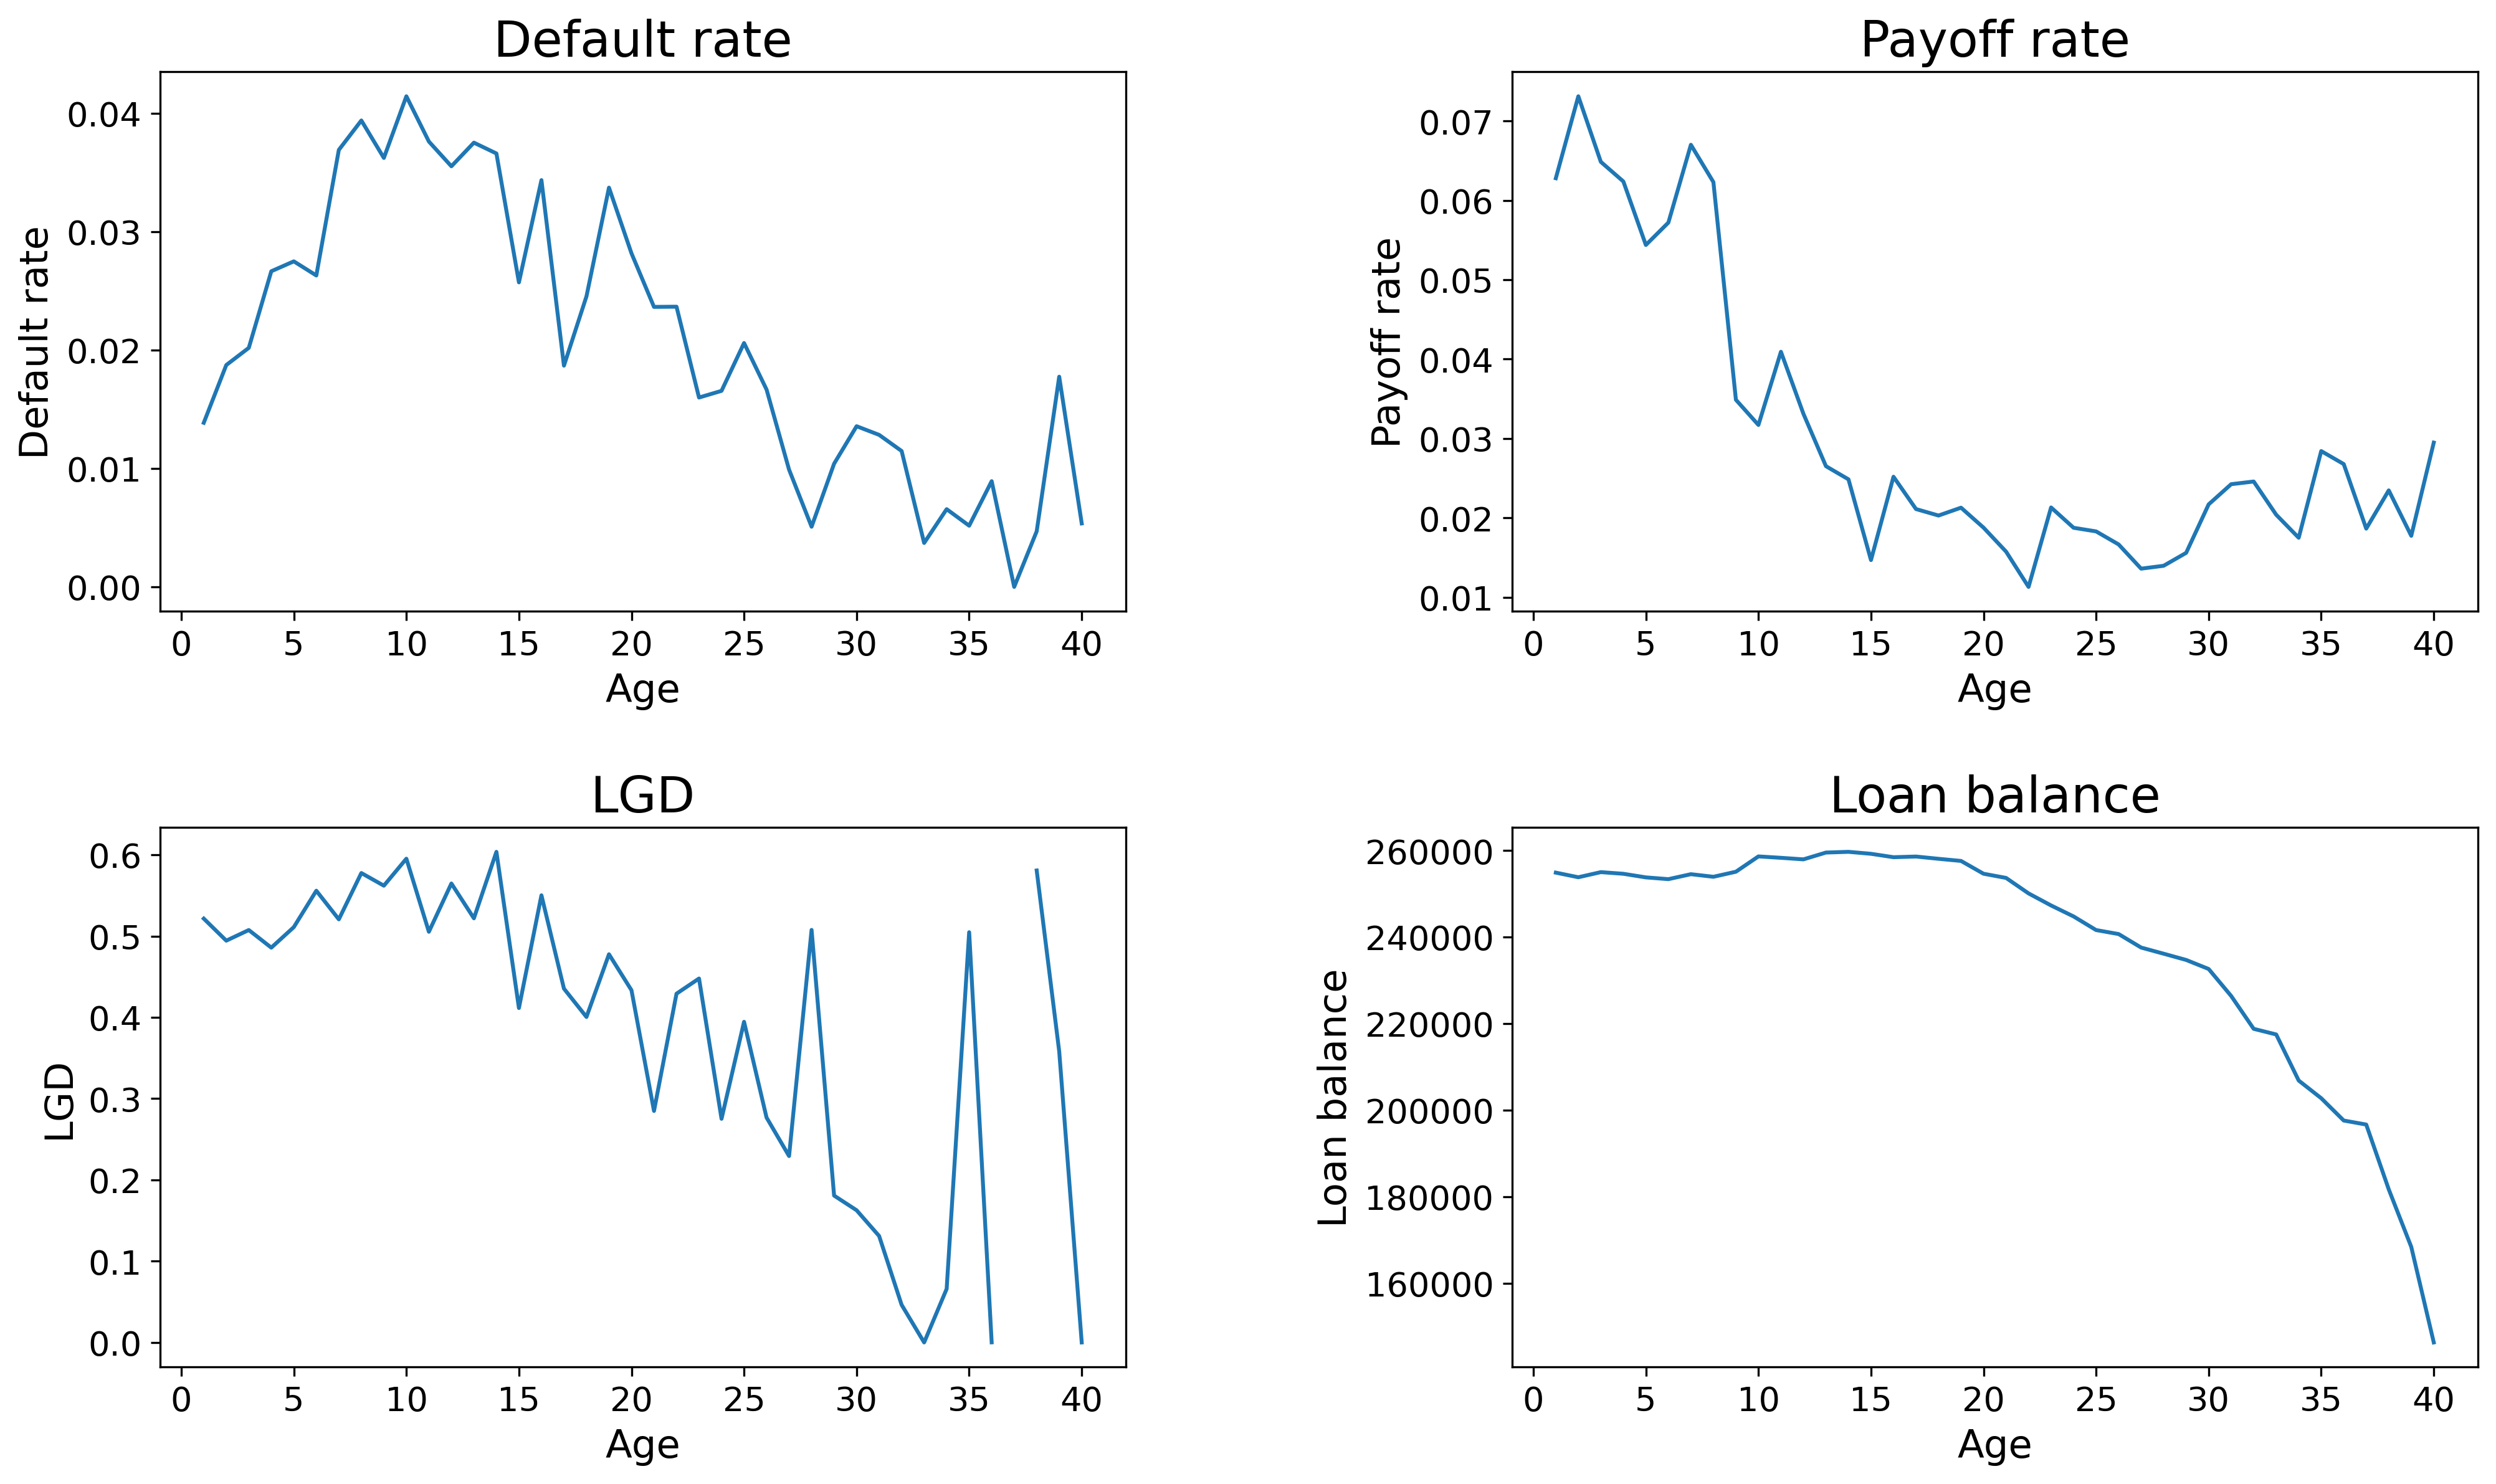

In [4]:
data_mean_age = data.groupby('age')[['default_time', 'payoff_time', 'lgd_time', 'balance_time']].mean().reset_index(drop=False)

plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.subplot(221)
plt.title('Default rate')
plt.plot('age', 'default_time', data=data_mean_age)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Default rate', fontsize=15)
plt.tick_params(axis='both', labelsize=13)

plt.subplot(222)
plt.title('Payoff rate')
plt.plot('age', 'payoff_time', data=data_mean_age)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Payoff rate', fontsize=15)
plt.tick_params(axis='both', labelsize=13)

plt.subplot(223)
plt.title('LGD')
plt.plot('age', 'lgd_time', data=data_mean_age)
plt.xlabel('Age', fontsize=15)
plt.ylabel('LGD', fontsize=15)
plt.tick_params(axis='both', labelsize=13)

plt.subplot(224)
plt.title('Loan balance')
plt.plot('age', 'balance_time', data=data_mean_age)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Loan balance', fontsize=15)
plt.tick_params(axis='both', labelsize=13)

plt.show()

In [5]:
model_lr0 = smf.glm('default_time ~ cep_time + equity_time + interest_rate_time + FICO_orig_time + gdp_time + PCA1_1 + PCA2_1 + PCA3_1 + PCA4_1 + PCA5_1 + cluster_1',
    family = sm.families.Binomial(), data=data).fit()

PD = pd.DataFrame(model_lr0.fittedvalues, columns=['PD'])

roll_rates = pd.merge(data[['id', 'time', 'default_time']], PD, right_index=True, left_index=True)

print(PD.describe().round(decimals=3))

              PD
count  59001.000
mean       0.025
std        0.023
min        0.001
25%        0.011
50%        0.018
75%        0.031
max        0.726


In [6]:
roll_rates.loc[:, 'rating1'], boundaries = pd.cut(roll_rates.PD, 5, labels=False, retbins=True)

print('Boundaries:', boundaries.round(decimals=2))

print('Frequency table of rating classes:')
print(pd.crosstab(roll_rates.rating1, columns='count', margins=True))

Boundaries: [0.   0.15 0.29 0.44 0.58 0.73]
Frequency table of rating classes:
col_0    count    All
rating1              
0        58799  58799
1          196    196
2            4      4
4            2      2
All      59001  59001


In [7]:
roll_rates.loc[:, 'rating2'], boundaries = pd.qcut(roll_rates.PD, 5, labels=False, retbins=True)

print('Boundaries:', boundaries.round(decimals=2))

print('Frequency table of rating classes:')
print(pd.crosstab(roll_rates.rating2, columns='count', margins=True))

Boundaries: [0.   0.01 0.01 0.02 0.04 0.73]
Frequency table of rating classes:
col_0    count    All
rating2              
0        11801  11801
1        11800  11800
2        11800  11800
3        11800  11800
4        11800  11800
All      59001  59001


In [8]:
roll_rates.loc[:, 'rating3'], boundaries = pd.cut(roll_rates.PD, [0, 0.02, 0.03, 0.04, 0.06, 0.96], labels=False, retbins=True)

print('Boundaries:', boundaries.round(decimals=2))

print('Frequency table of rating classes:')
print(pd.crosstab(roll_rates.rating3, columns='count', margins=True))

Boundaries: [0.   0.02 0.03 0.04 0.06 0.96]
Frequency table of rating classes:
col_0    count    All
rating3              
0        32514  32514
1        10978  10978
2         6035   6035
3         5478   5478
4         3996   3996
All      59001  59001


In [9]:
rating1d = roll_rates.groupby('rating1')['default_time'].mean().reset_index(drop=False).rename(columns={'default_time': 'rating1d'})
rating2d = roll_rates.groupby('rating2')['default_time'].mean().reset_index(drop=False).rename(columns={'default_time': 'rating2d'})
rating3d = roll_rates.groupby('rating3')['default_time'].mean().reset_index(drop=False).rename(columns={'default_time': 'rating3d'})

roll_rates = pd.merge(roll_rates, rating1d, on='rating1')
roll_rates = pd.merge(roll_rates, rating2d, on='rating2')
roll_rates = pd.merge(roll_rates, rating3d, on='rating3')

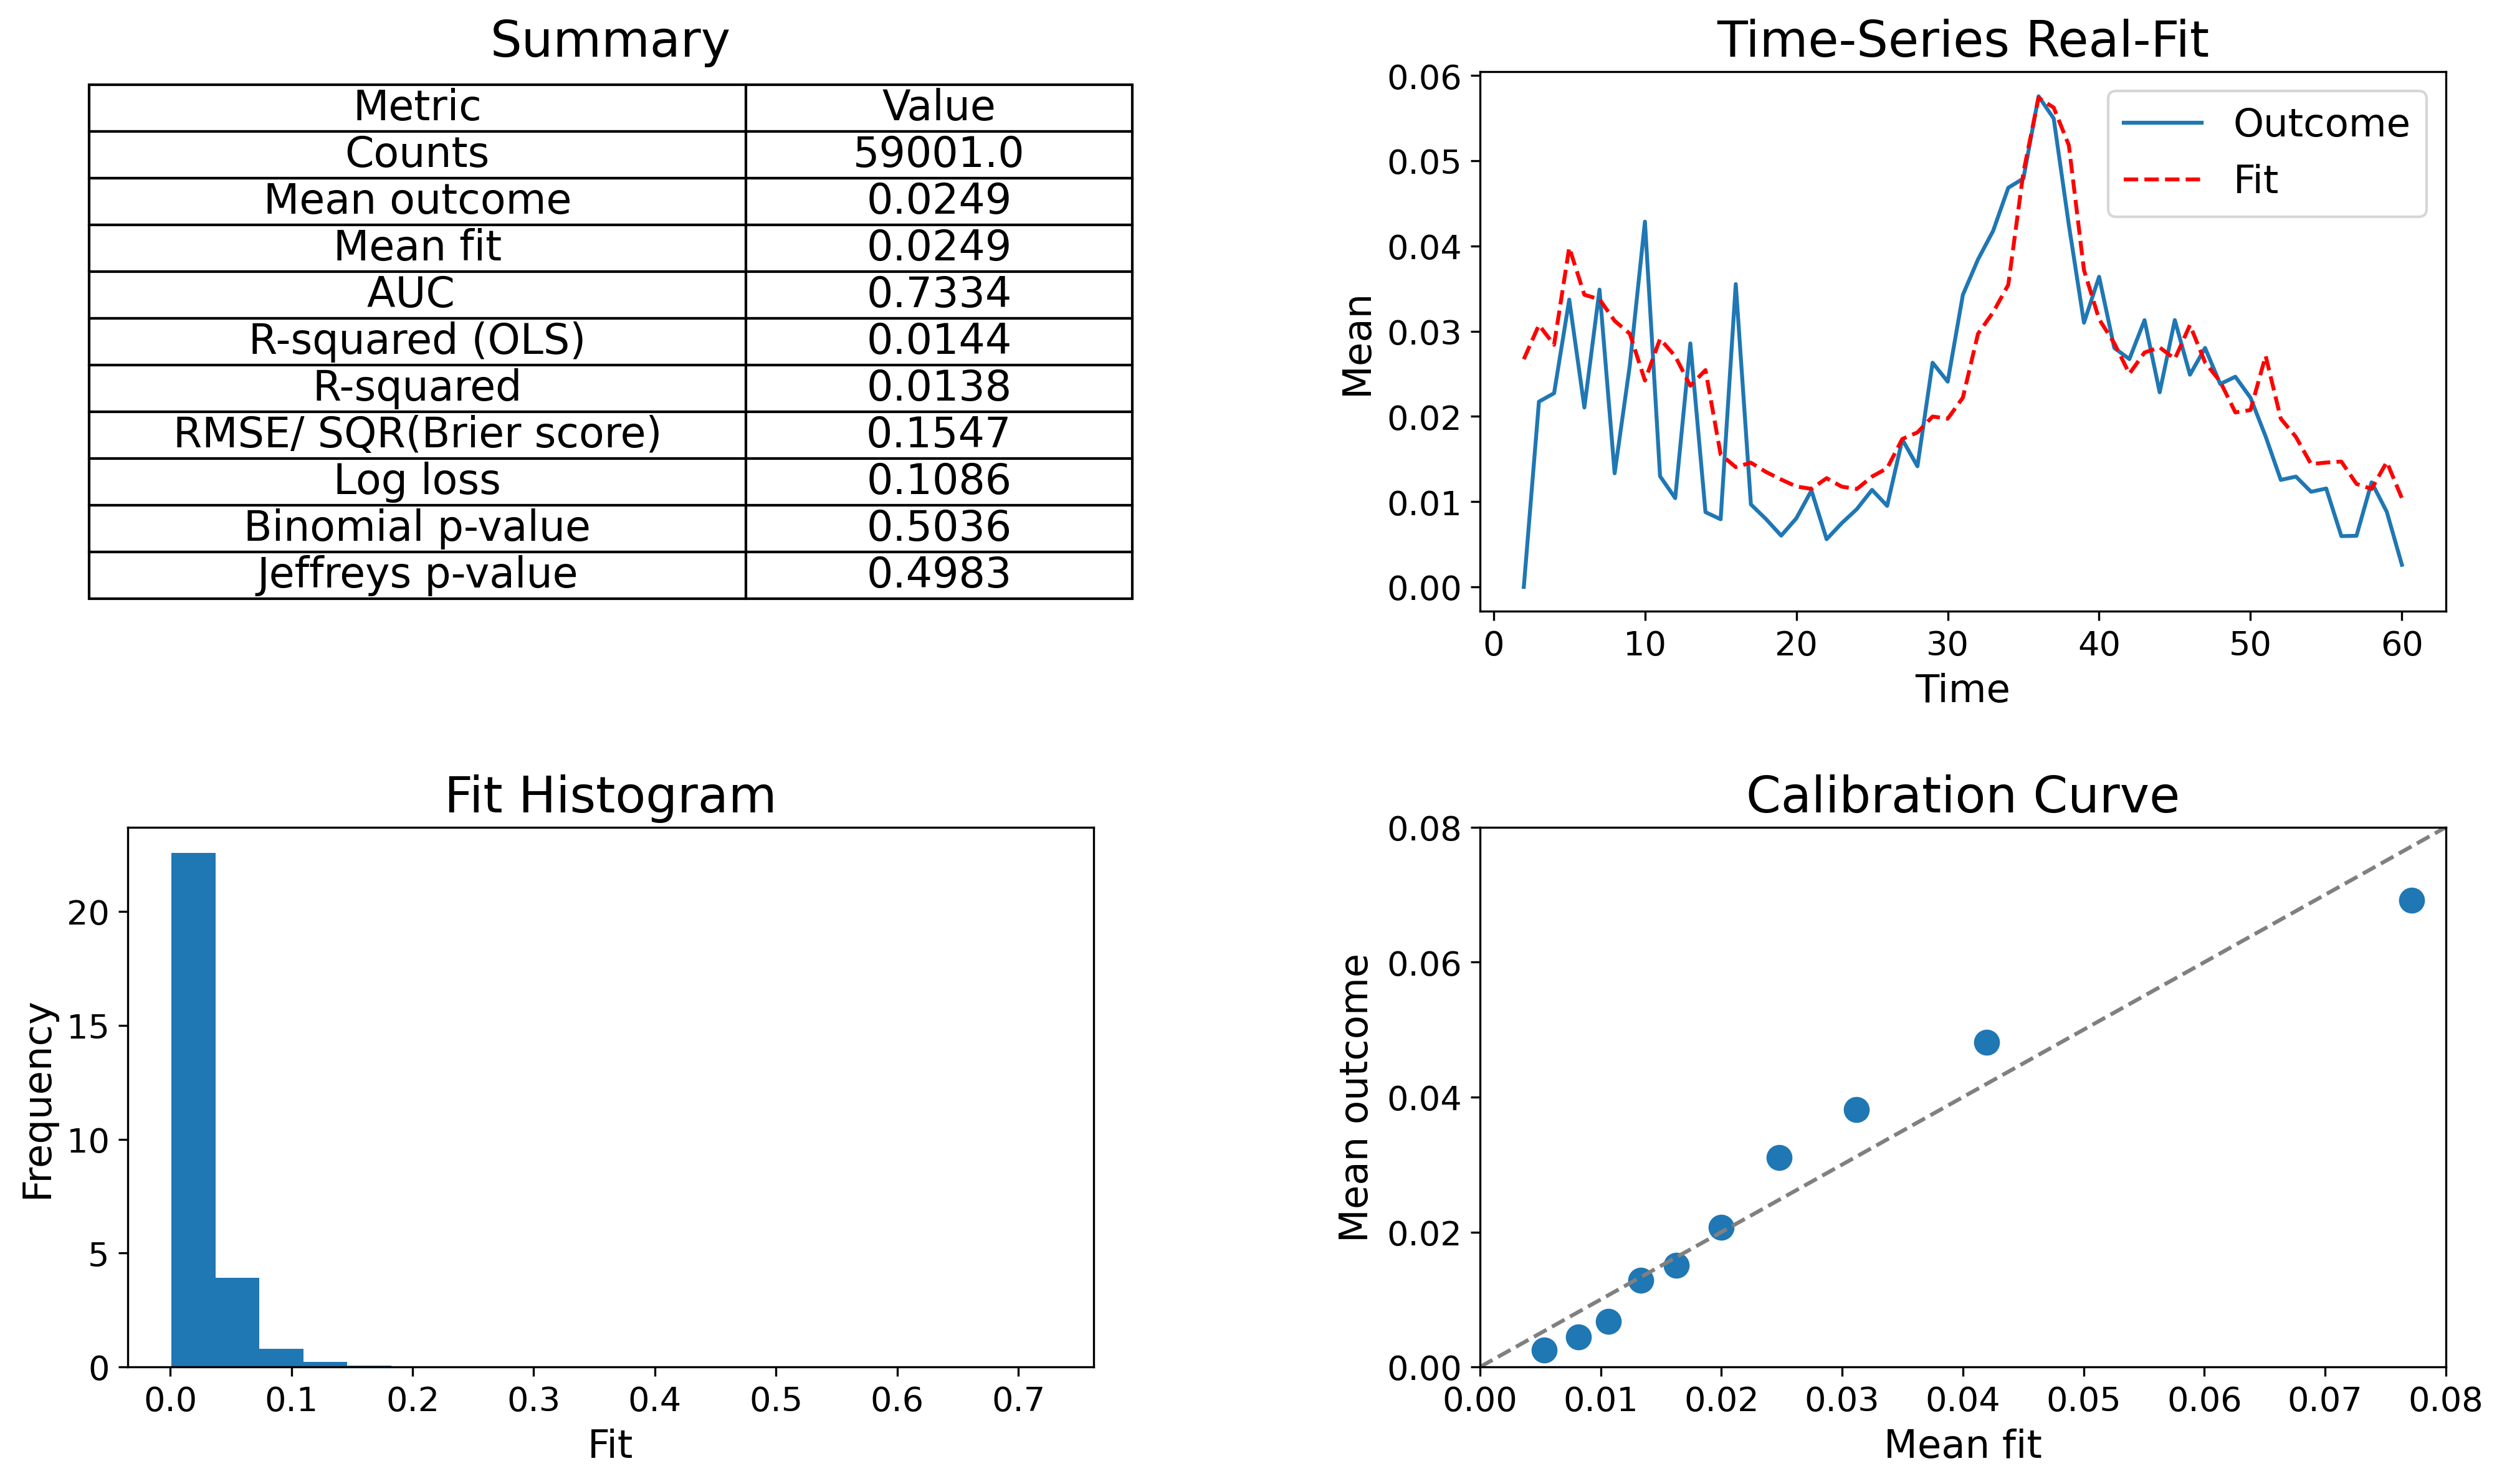

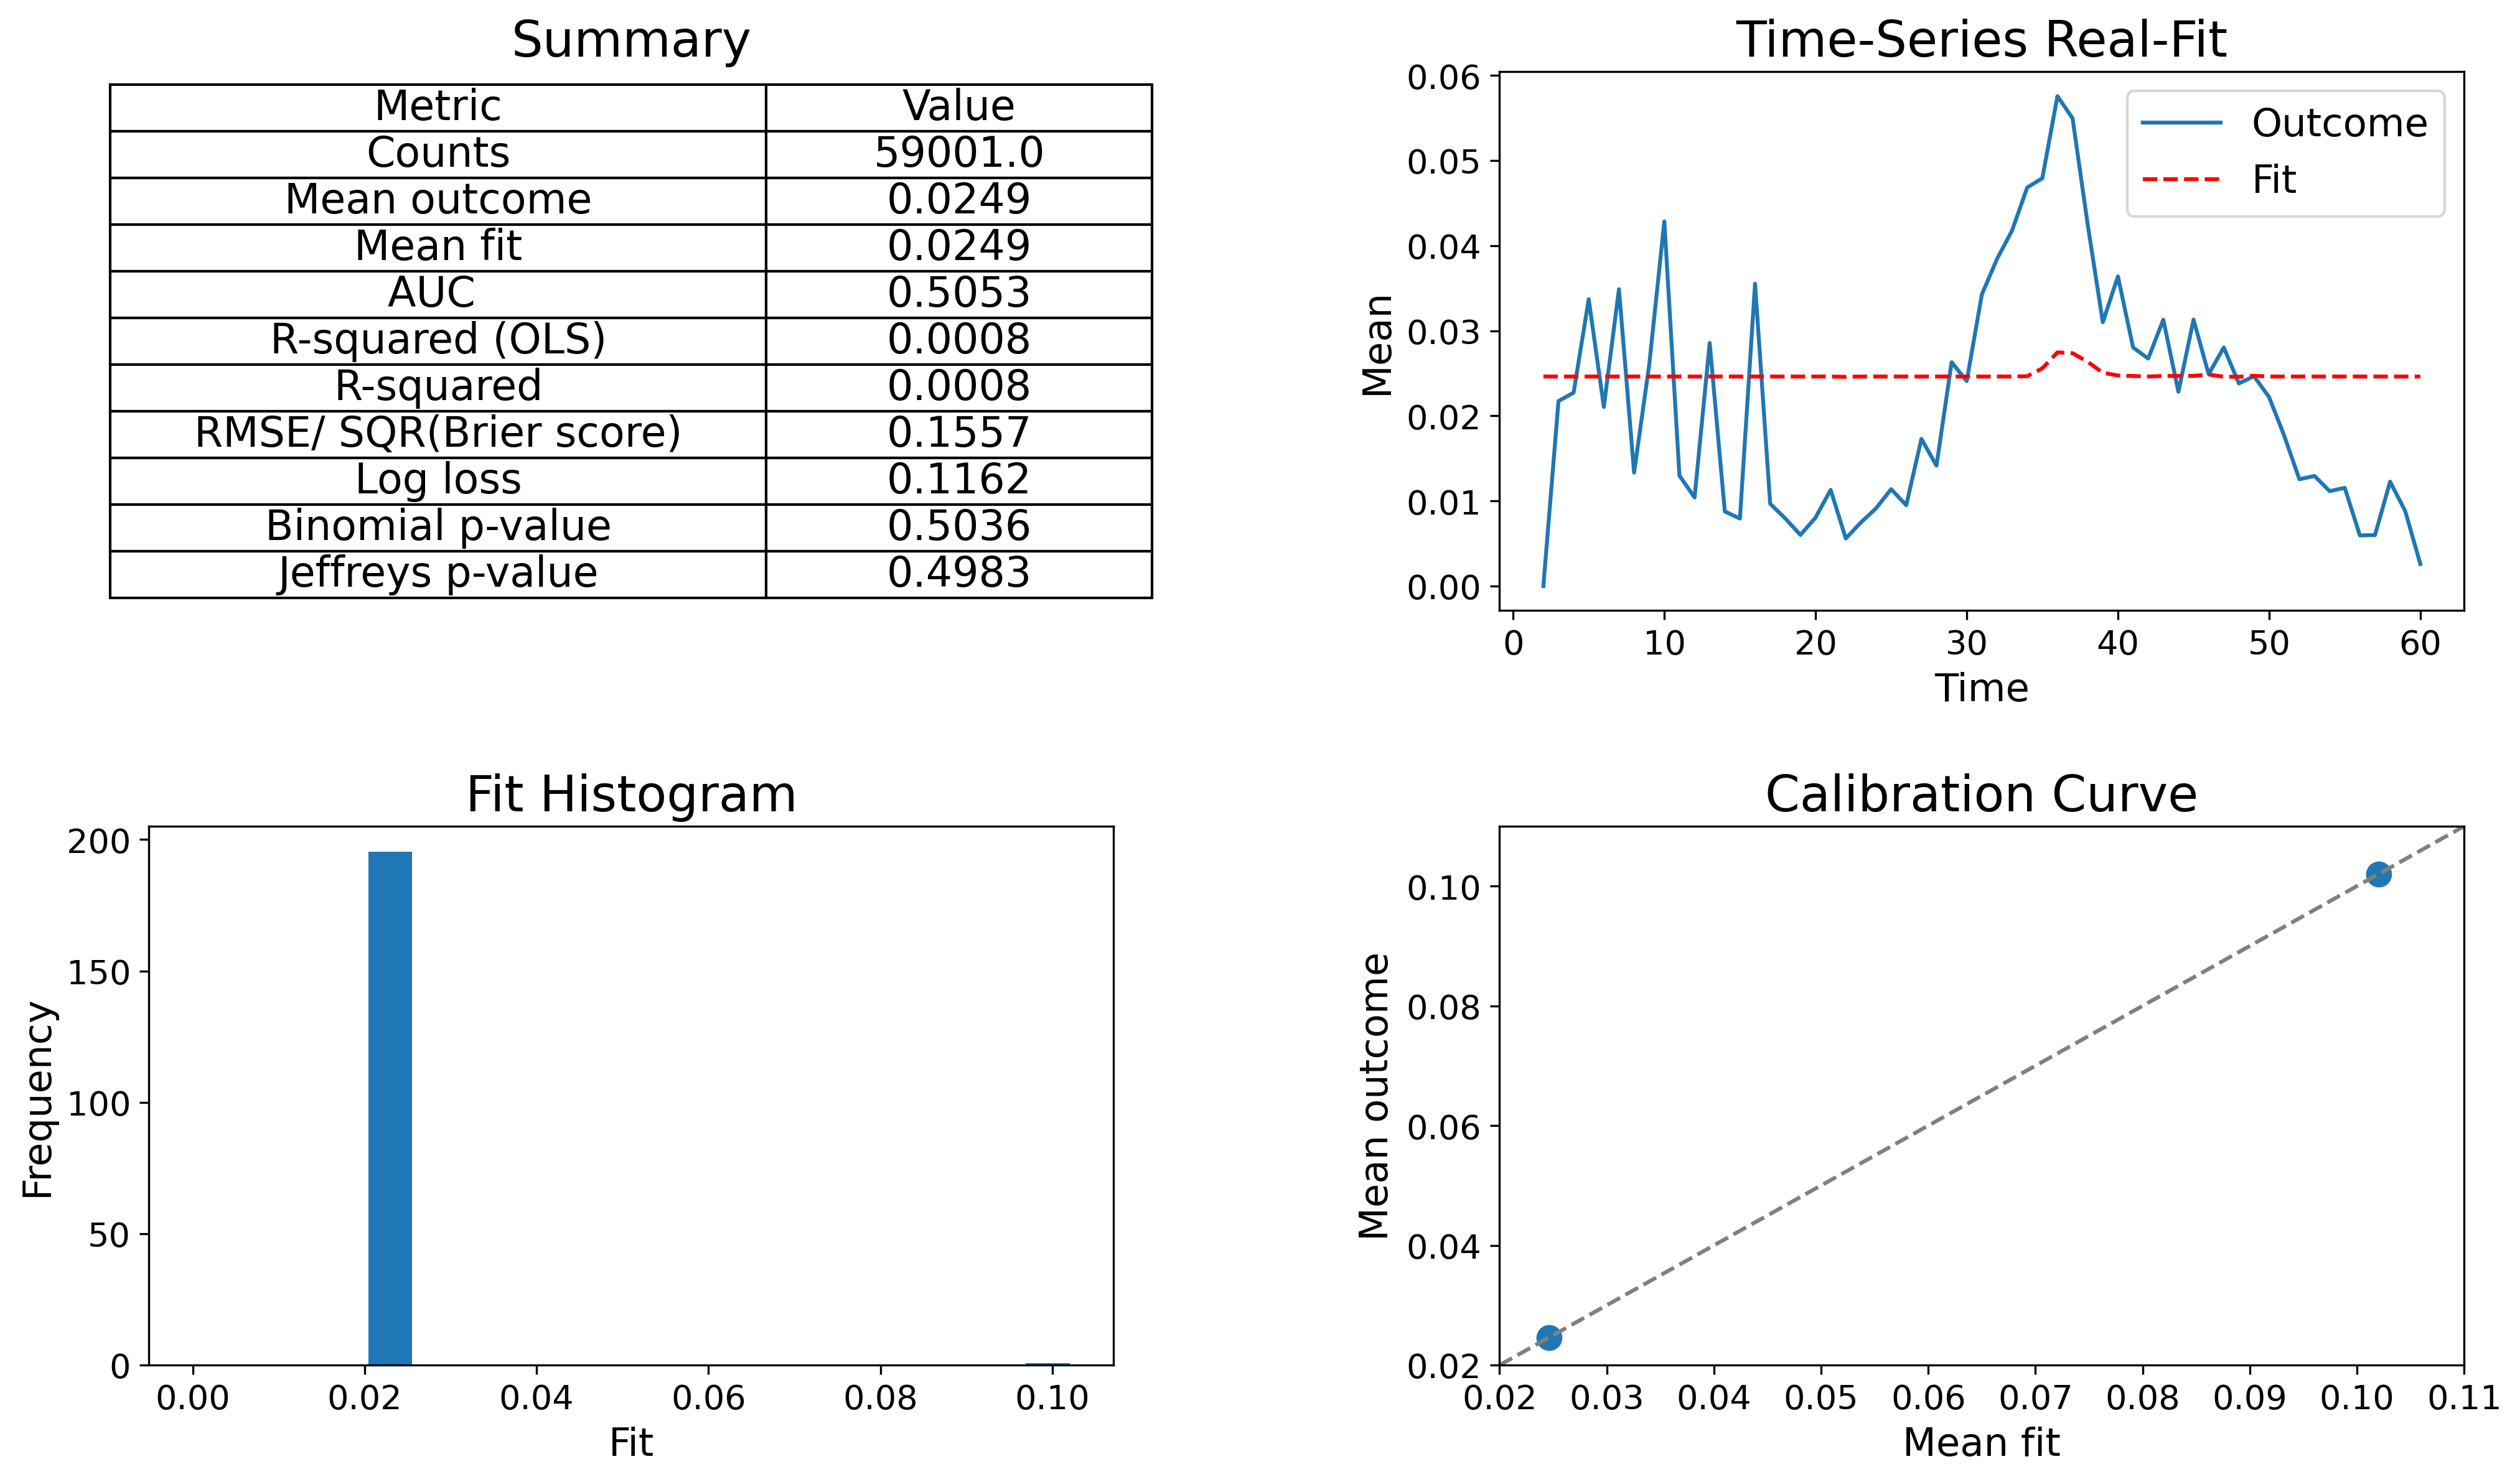

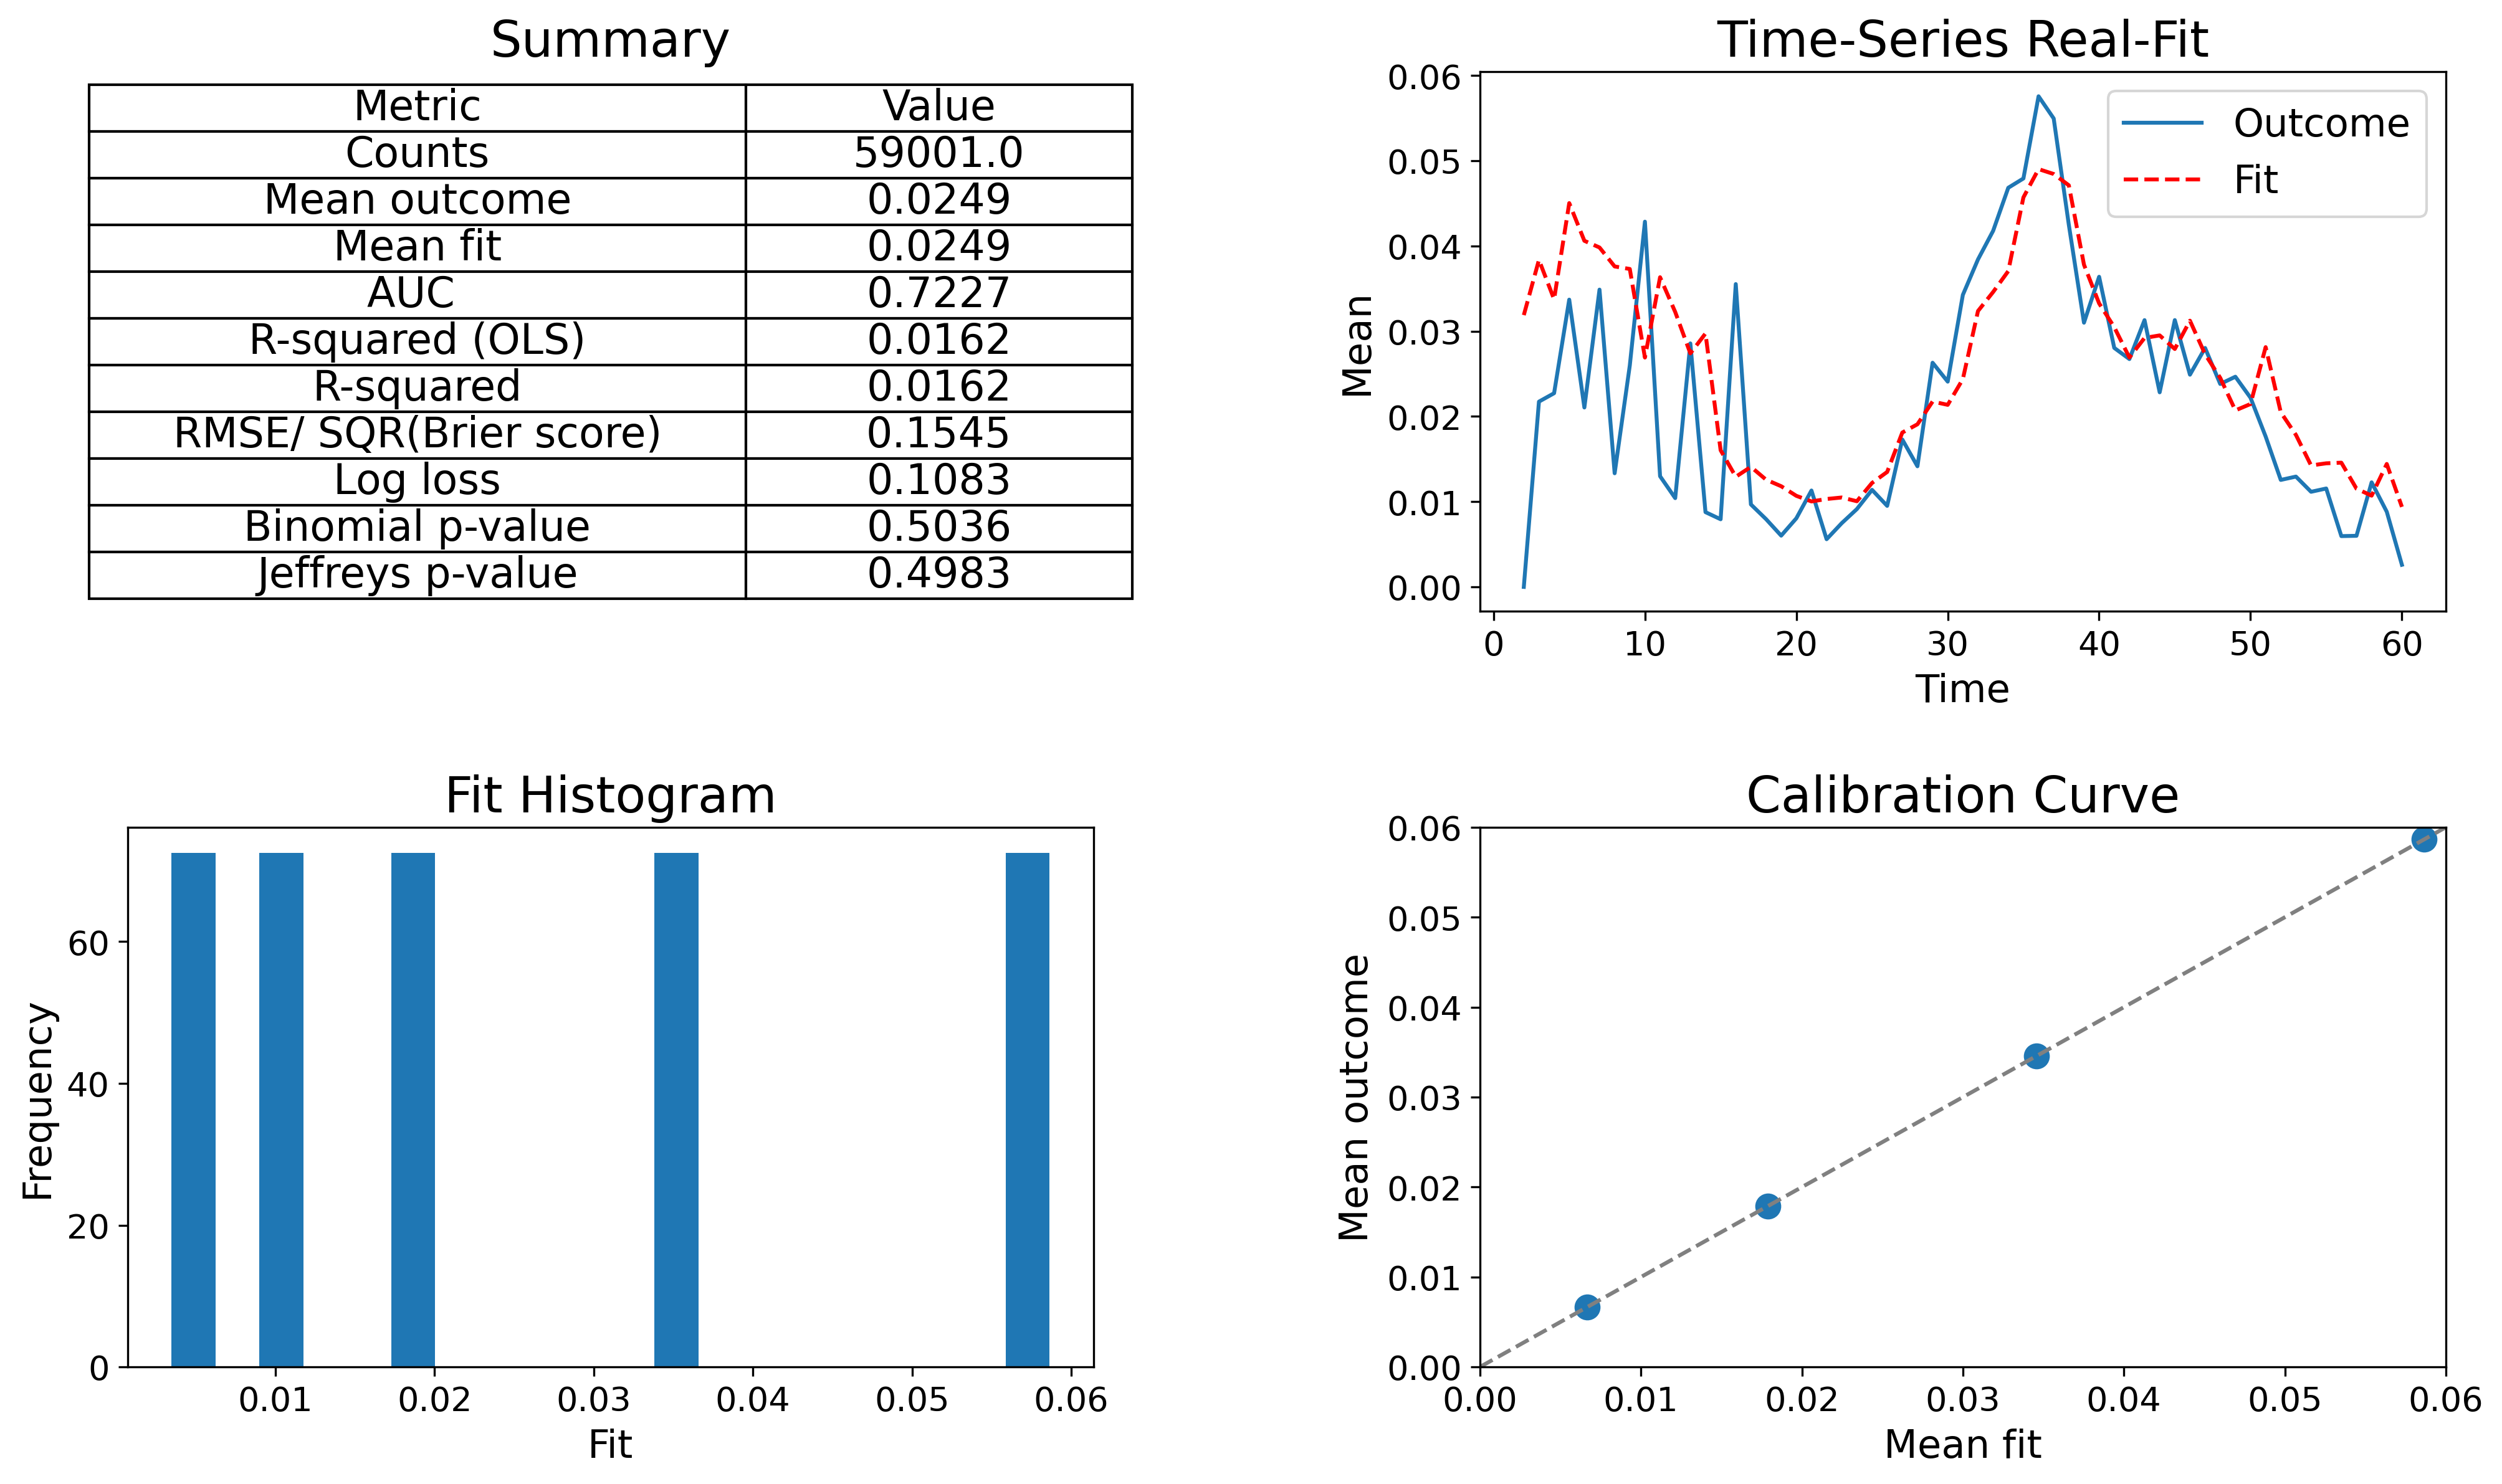

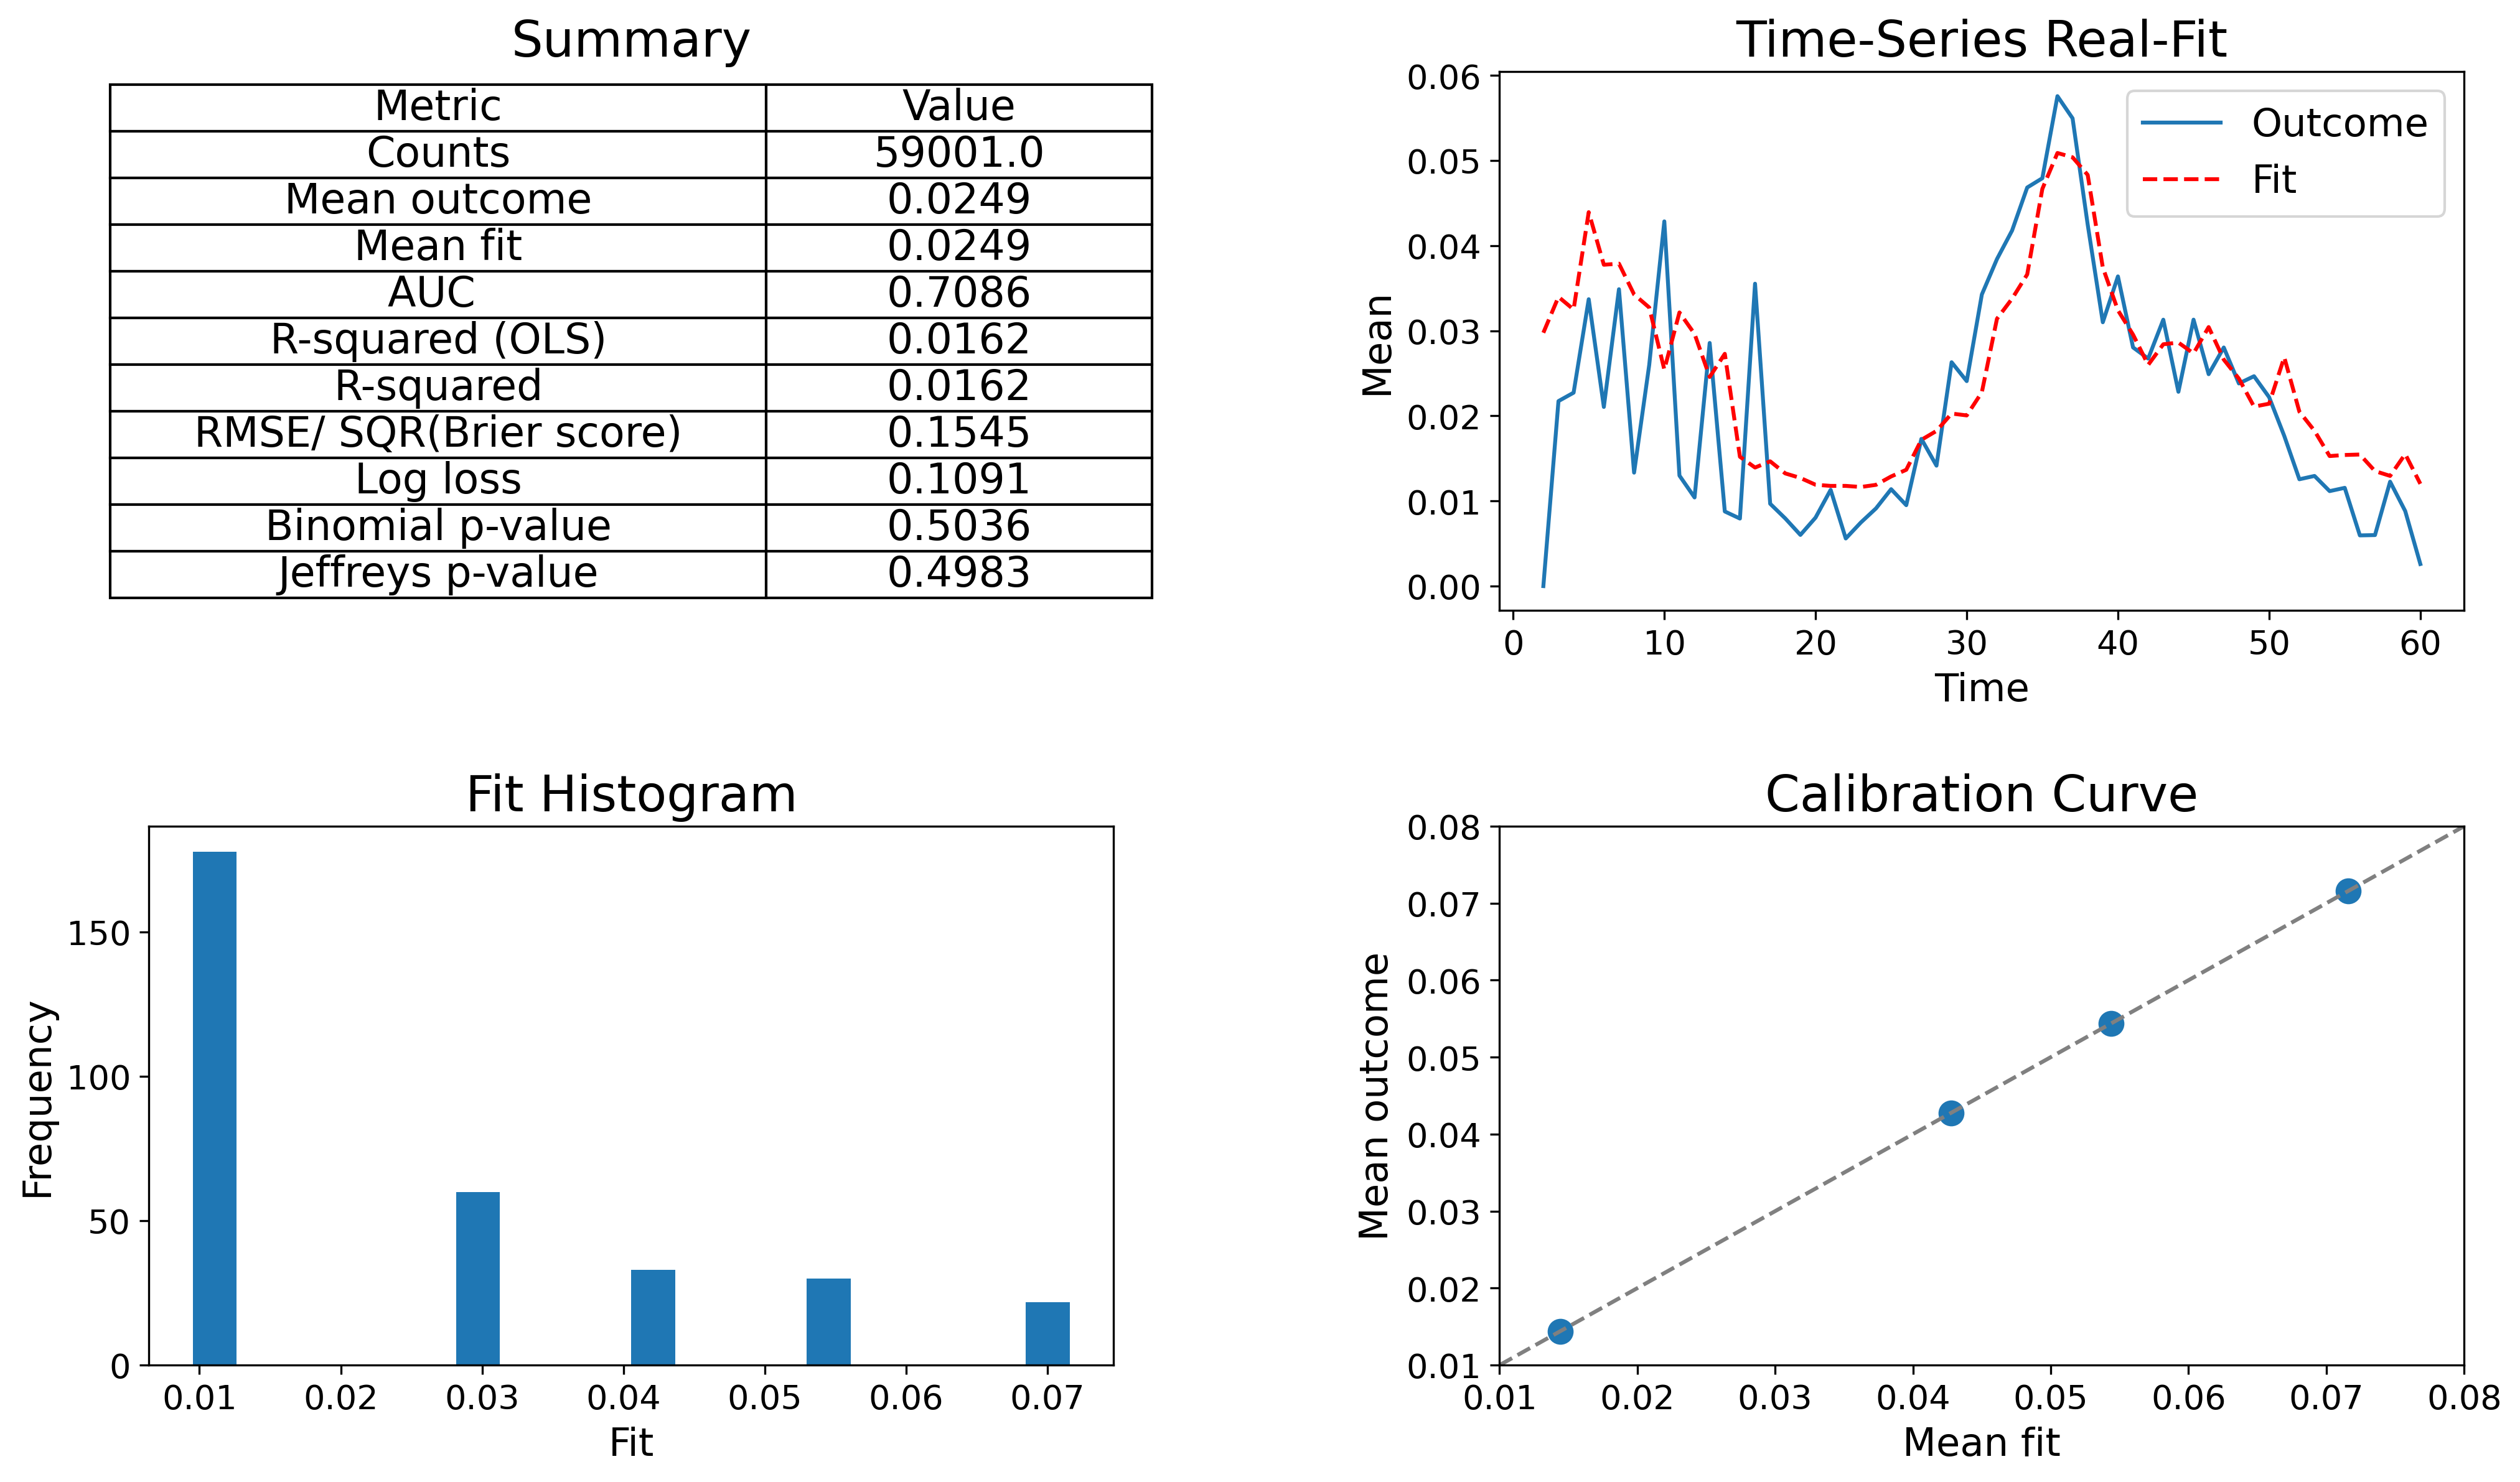

In [10]:
validation(roll_rates.PD, roll_rates.default_time, roll_rates.time)
validation(roll_rates.rating1d, roll_rates.default_time, roll_rates.time)
validation(roll_rates.rating2d, roll_rates.default_time, roll_rates.time)
validation(roll_rates.rating3d, roll_rates.default_time, roll_rates.time)

In [19]:
roll_rates2 = roll_rates.sort_values(['id', 'time'], ascending=[1,1])

lagid = (roll_rates2[['id']]).shift(1).copy()
lagid.columns = ['lagid']

lagrating2 = (roll_rates2[['rating2']]).shift(1).copy()
lagrating2.columns = ['lagrating2']
lagrating2[roll_rates2[['id']].values != lagid[['lagid']].values] = np.nan

rating2 = roll_rates2[['rating2']].copy()
rating2.loc[roll_rates2.default_time == 1, 'rating2'] = 5

roll_rates3 = pd.concat([roll_rates2.id, roll_rates2.time, lagrating2, rating2], axis=1).copy()

extra_row = pd.DataFrame([{'id': 0, 'time': 0, 'lagrating2': 5, 'rating2': 5}])
roll_rates3 = pd.concat([roll_rates3, extra_row], ignore_index=True)

roll_rates3 = roll_rates3.dropna().copy()

In [20]:
table_absolute = pd.crosstab(roll_rates3.lagrating2, roll_rates3.rating2, margins=True).copy()

print(table_absolute.drop('All', axis='columns').drop('All', axis='rows').round(decimals=2))

rating2        0     1     2     3     4    5
lagrating2                                   
0.0         9688  1009     9     2     0   32
1.0         1096  7952  1657    24     0  121
2.0           38  1376  7290  1938    18  253
3.0           11    62  1350  7418  1678  389
4.0            2    13    40  1148  8992  607
5.0            0     0     0     0     0    1


In [21]:
table1 = table_absolute.div(table_absolute.iloc[:,6], axis='rows').iloc[0:6, 0:6]

print(table1.round(decimals=2))

rating2       0     1     2     3     4     5
lagrating2                                   
0.0         0.9  0.09  0.00  0.00  0.00  0.00
1.0         0.1  0.73  0.15  0.00  0.00  0.01
2.0         0.0  0.13  0.67  0.18  0.00  0.02
3.0         0.0  0.01  0.12  0.68  0.15  0.04
4.0         0.0  0.00  0.00  0.11  0.83  0.06
5.0         0.0  0.00  0.00  0.00  0.00  1.00


In [22]:
table2 = table1.dot(table1)

print(table2.round(decimals=2))

rating2        0     1     2     3     4     5
lagrating2                                    
0.0         0.82  0.15  0.02  0.00  0.00  0.01
1.0         0.17  0.57  0.21  0.03  0.00  0.02
2.0         0.02  0.18  0.49  0.24  0.03  0.05
3.0         0.00  0.02  0.17  0.50  0.23  0.07
4.0         0.00  0.00  0.02  0.16  0.71  0.11
5.0         0.00  0.00  0.00  0.00  0.00  1.00


In [23]:
table3 = table2.dot(table1)
table4 = table3.dot(table1)
table5 = table4.dot(table1)
table6 = table5.dot(table1)
table7 = table6.dot(table1)
table8 = table7.dot(table1)
table9 = table8.dot(table1)
table10 = table9.dot(table1)

cumDefault = pd.DataFrame(np.zeros(6))
cumDefault.loc[:,'1'] = table1.iloc[:,5]
cumDefault.loc[:,'2'] = table2.iloc[:,5]
cumDefault.loc[:,'3'] = table3.iloc[:,5]
cumDefault.loc[:,'4'] = table4.iloc[:,5]
cumDefault.loc[:,'5'] = table5.iloc[:,5]
cumDefault.loc[:,'6'] = table6.iloc[:,5]
cumDefault.loc[:,'7'] = table7.iloc[:,5]
cumDefault.loc[:,'8'] = table8.iloc[:,5]
cumDefault.loc[:,'9'] = table9.iloc[:,5]
cumDefault.loc[:,'10'] = table10.iloc[:,5]

cumDefault2 = cumDefault.transpose().reset_index()
cumDefault2.columns = ['period', 'class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'default']


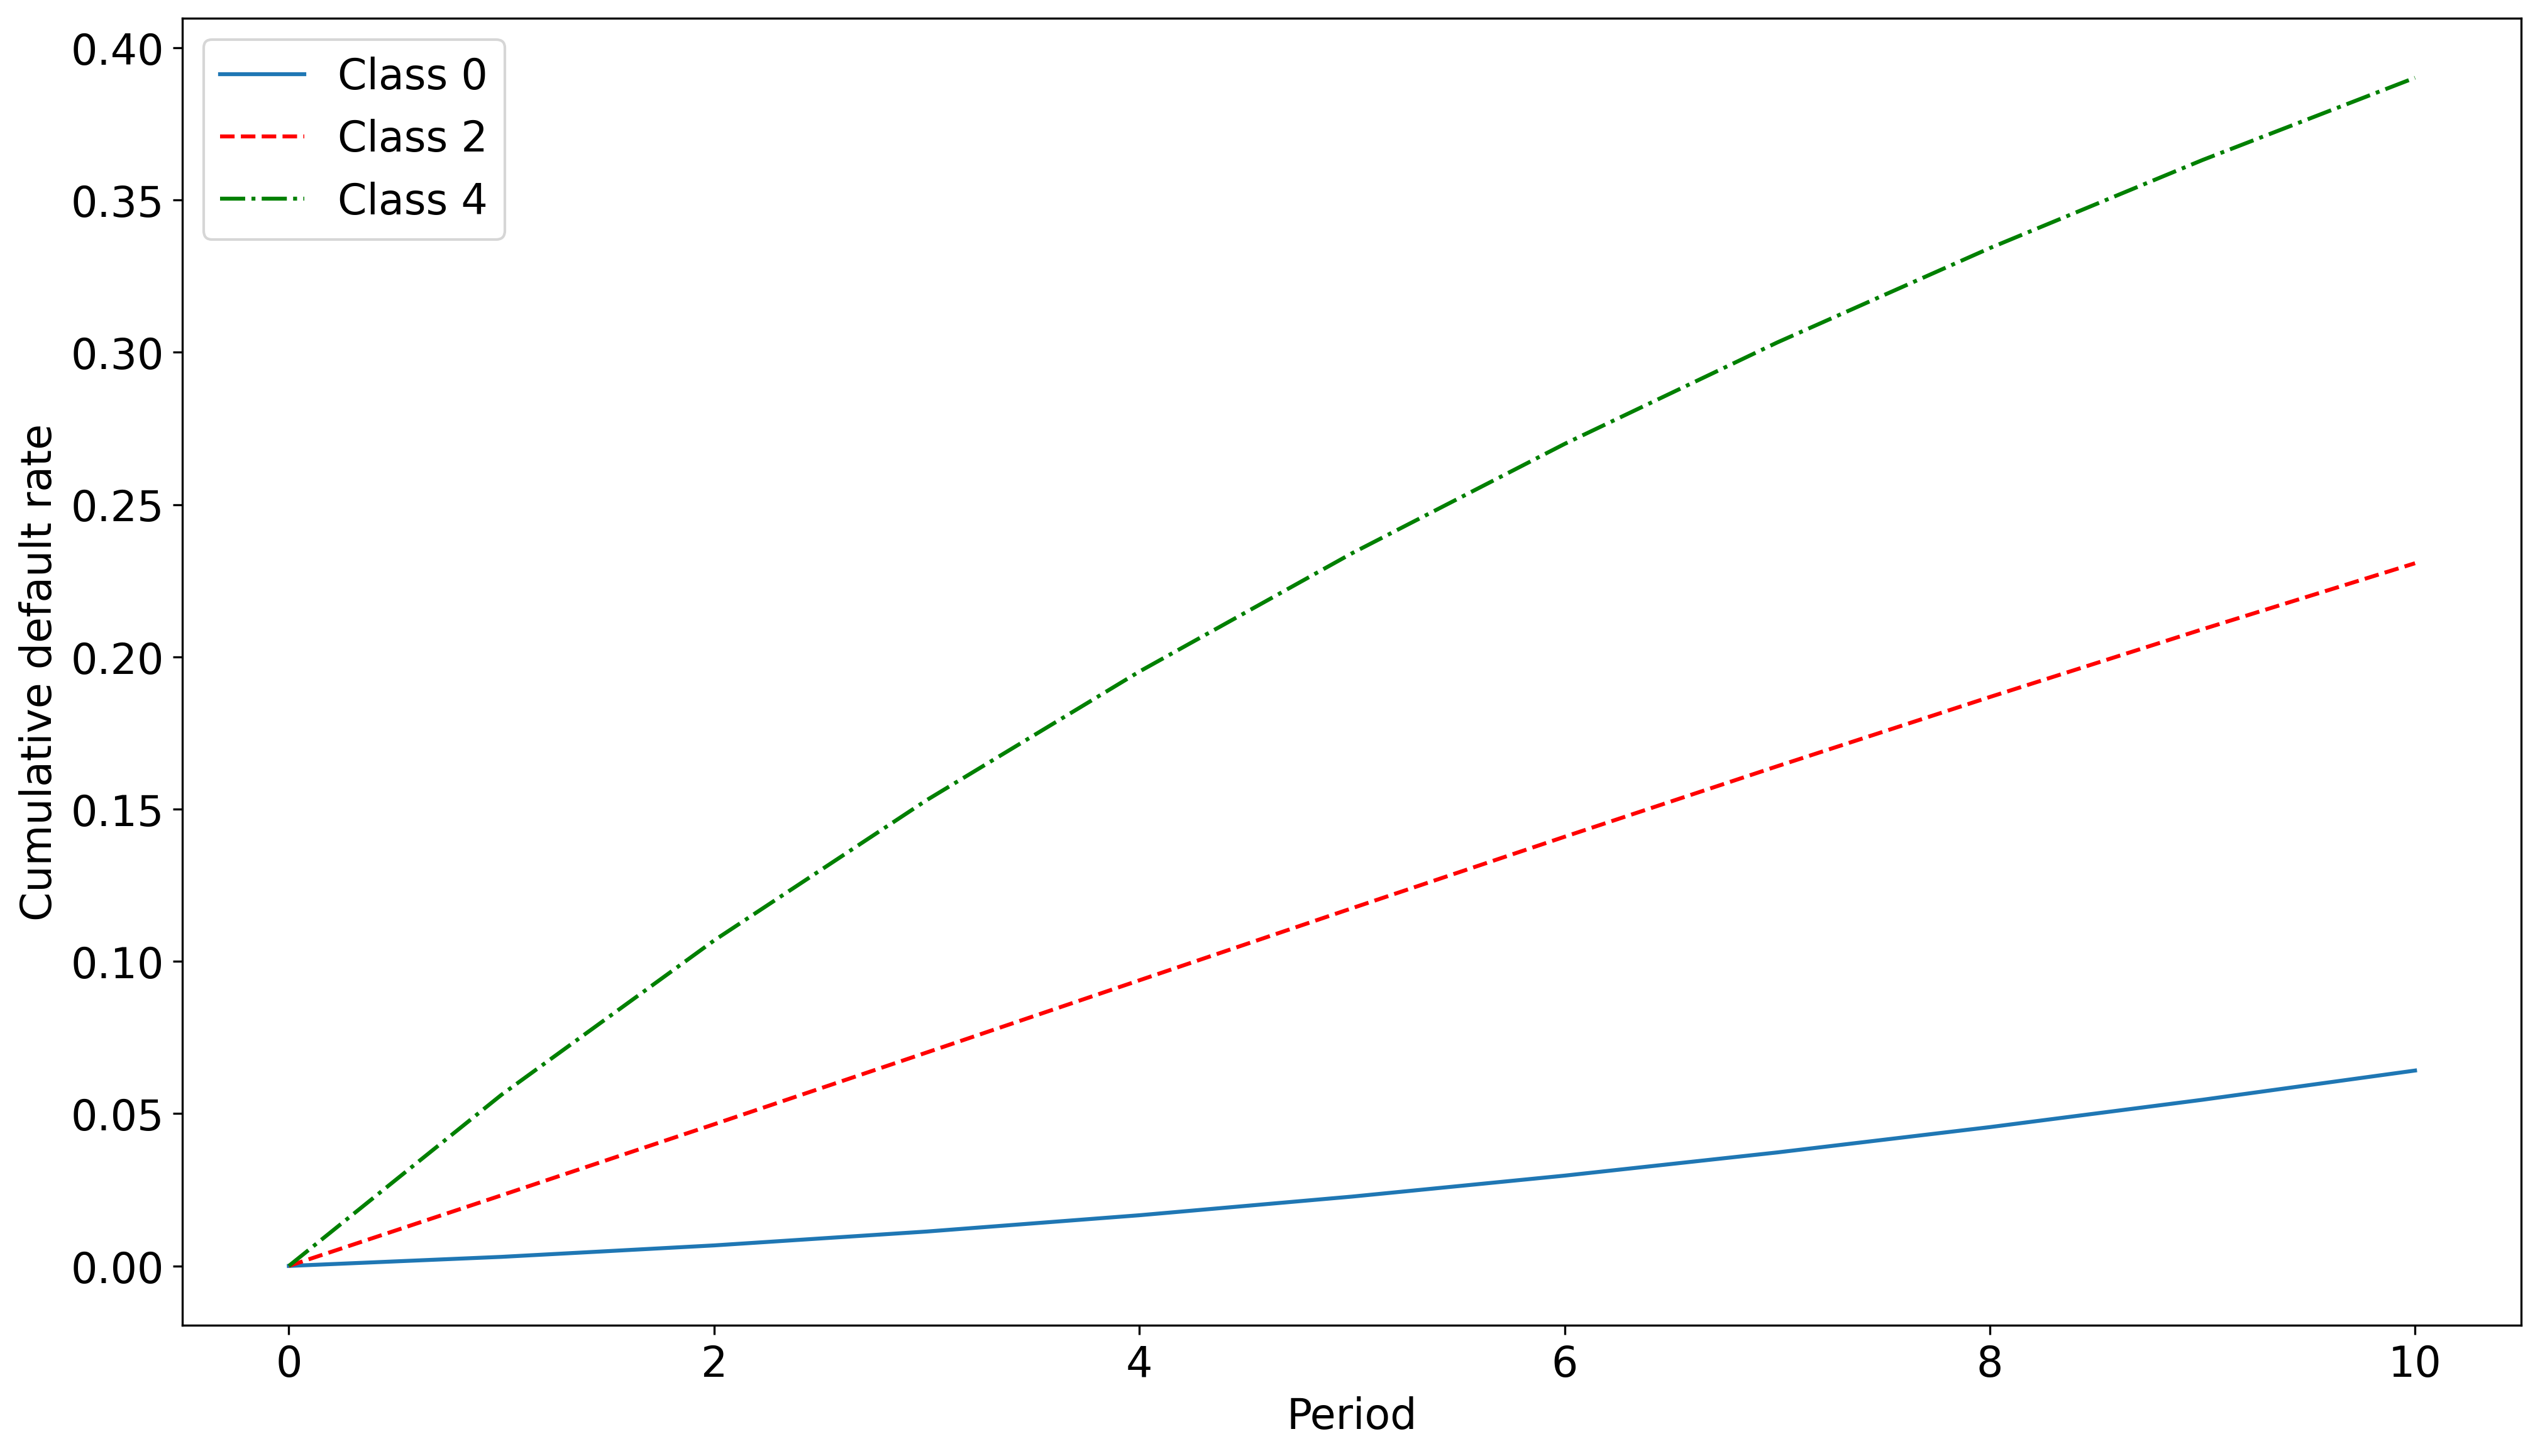

In [24]:
plt.plot(cumDefault2.period, cumDefault2.class_0, label='Class 0')
plt.plot(cumDefault2.period, cumDefault2.class_2, color='red', label='Class 2', linestyle='dashed')
plt.plot(cumDefault2.period, cumDefault2.class_4, color='green', label='Class 4', linestyle='dashdot')

plt.xlabel('Period')
plt.ylabel('Cumulative default rate')
plt.legend(loc='best')
plt.show()

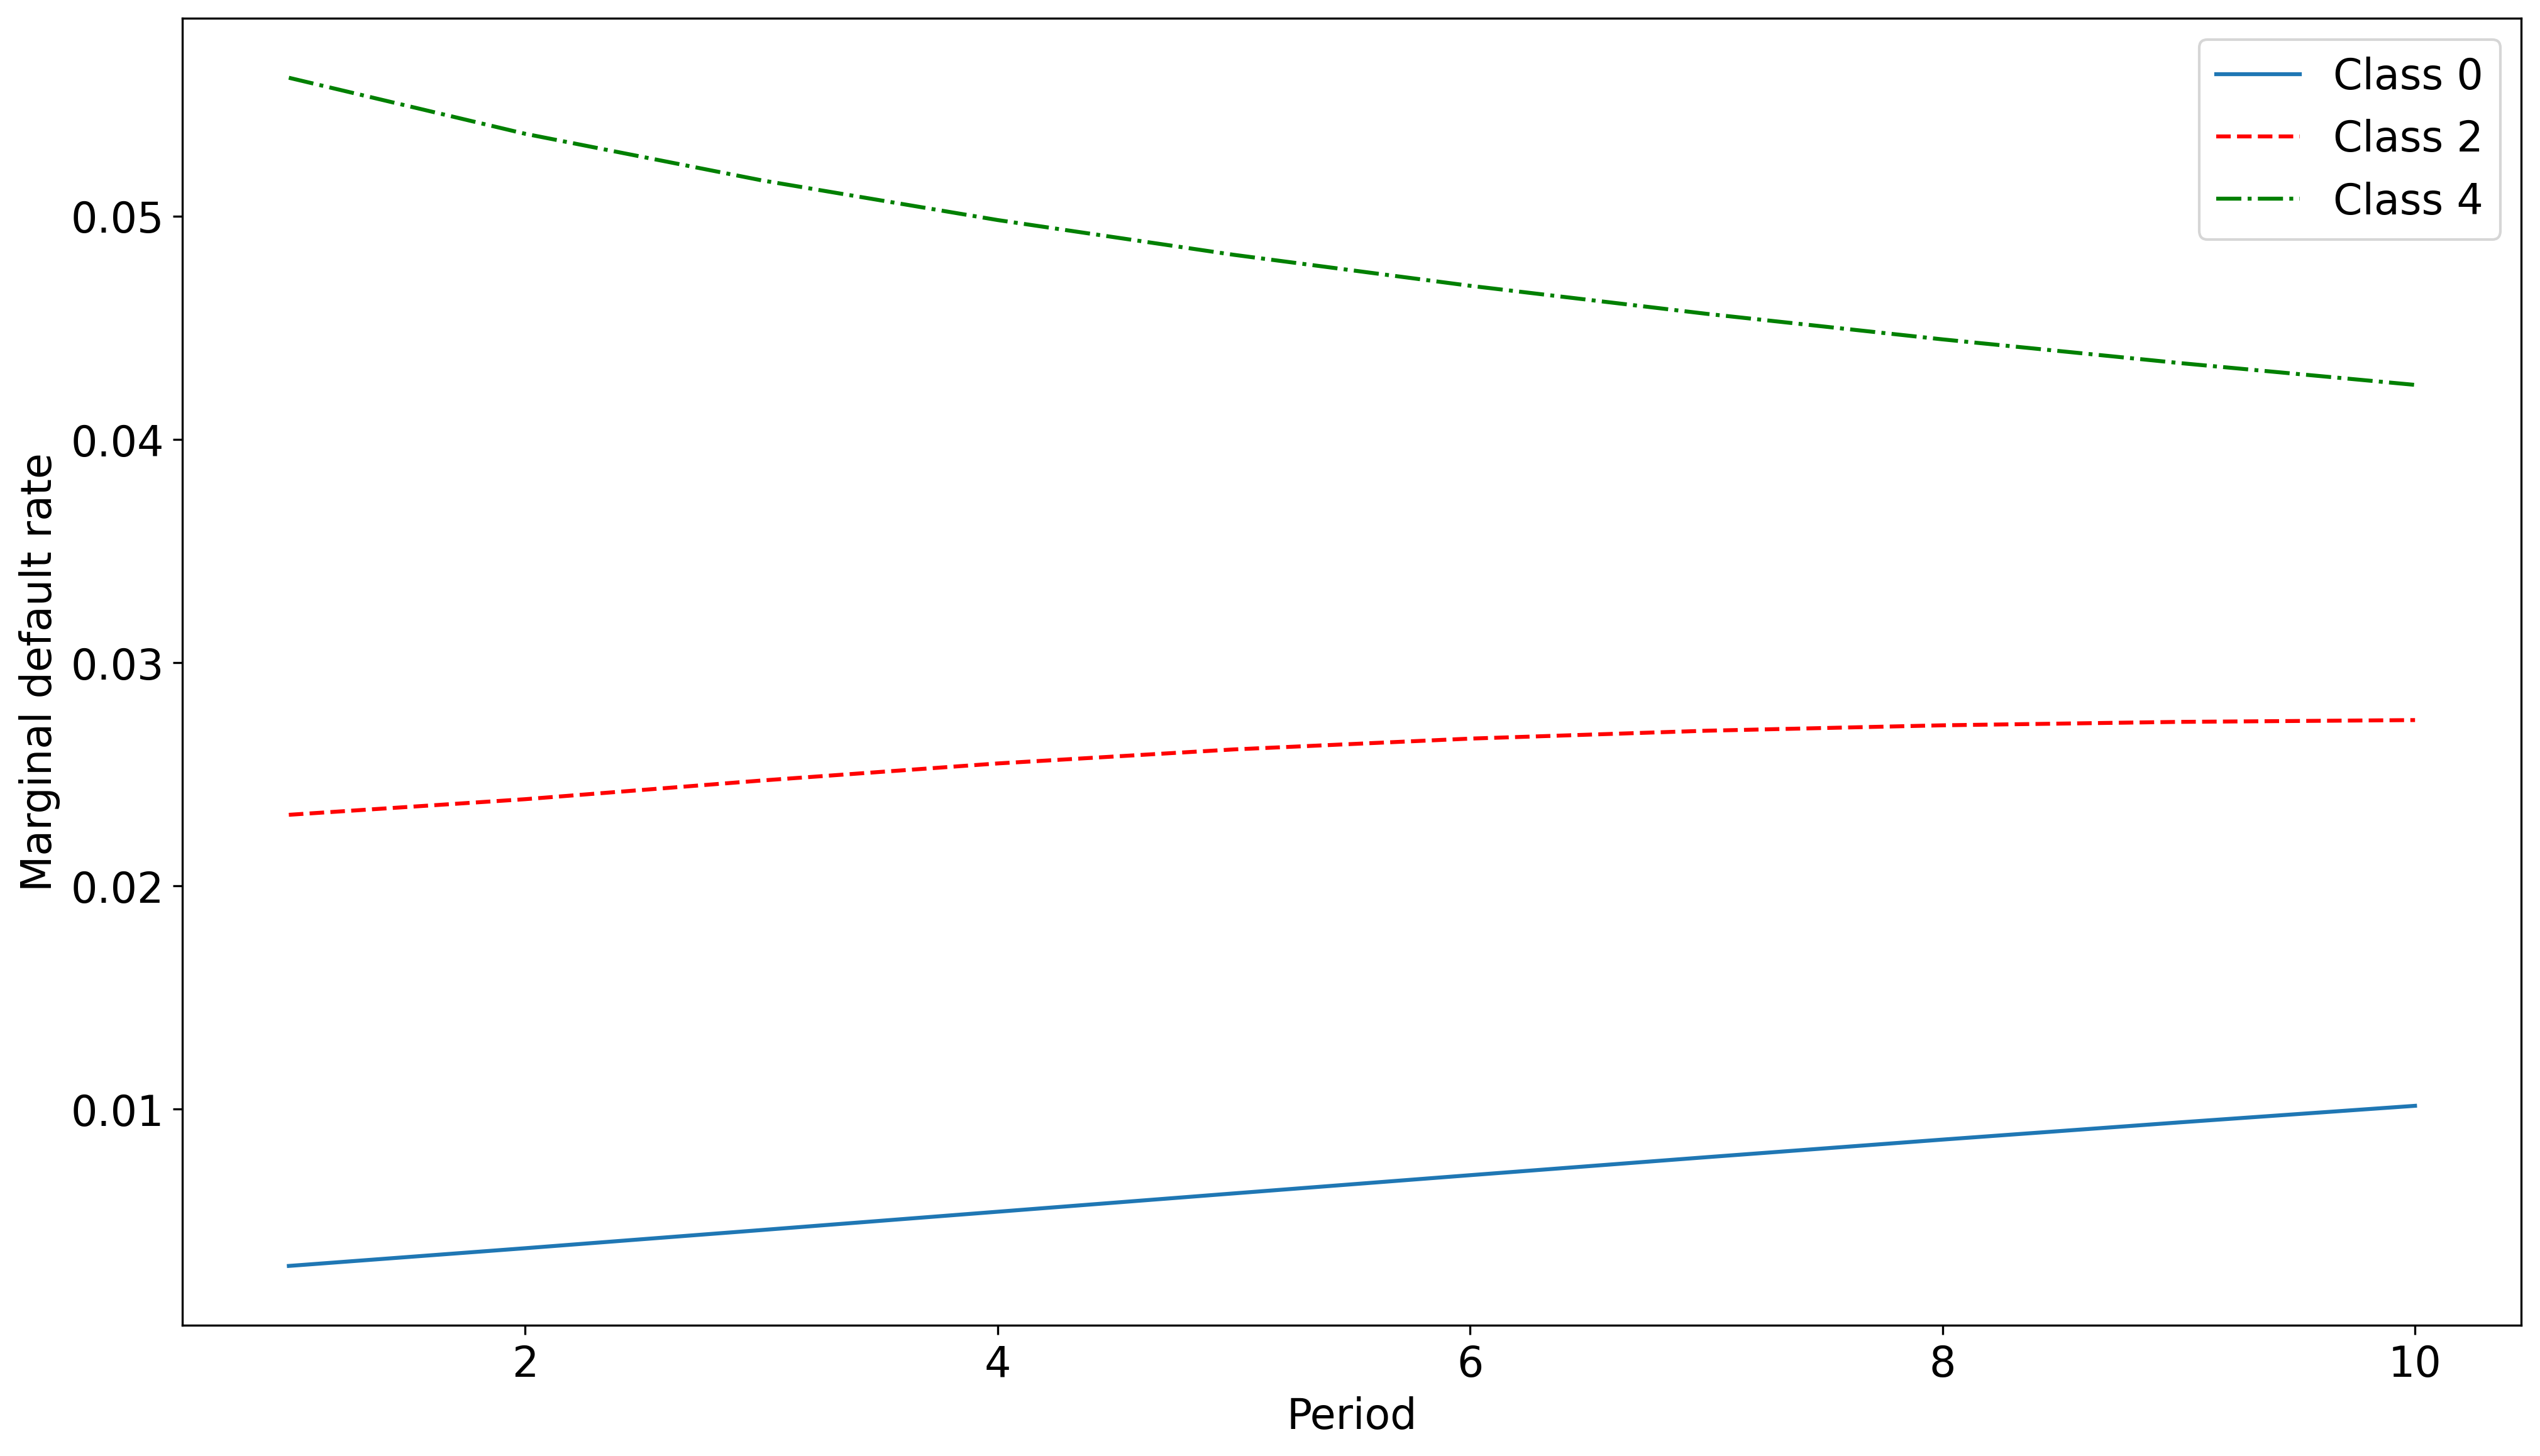

In [25]:
cumDefault2 = cumDefault2.drop('period', axis='columns')
cumDefault2_1 = cumDefault2.shift(1)
margDefault = (cumDefault2 - cumDefault2_1) / (1 - cumDefault2_1)

plt.plot(margDefault.index, margDefault.class_0, label='Class 0')
plt.plot(margDefault.index, margDefault.class_2, color='red', label='Class 2', linestyle='dashed')
plt.plot(margDefault.index, margDefault.class_4, color='green', label='Class 4', linestyle='dashdot')

plt.xlabel('Period')
plt.ylabel('Marginal default rate')
plt.legend(loc='best')
plt.show()

In [26]:
model_lr1 = smf.glm('default_time~cep_time + equity_time + interest_rate_time + FICO_orig_time + gdp_time + PCA1_1 + PCA2_1 + PCA3_1 + PCA4_1 + PCA5_1 + cluster_1 + age + age2',
                    family = sm.families.Binomial(), data = data).fit()

print(model_lr1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58987
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6398.5
Date:                Sun, 24 Aug 2025   Deviance:                       12797.
Time:                        16:50:53   Pearson chi2:                 5.61e+04
No. Iterations:                     8   Pseudo R-squ. (CS):            0.01592
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -2.3212      0

In [27]:
data2 = data
data2.loc[:, 'age_c'] = pd.Categorical(data.age, ordered=False)

model_lr2 = smf.glm('default_time~cep_time + equity_time + interest_rate_time + FICO_orig_time + gdp_time + PCA1_1 + PCA2_1 + PCA3_1 + PCA4_1 + PCA5_1 + cluster_1 + age_c',
                     family = sm.families.Binomial(), data = data2).fit()

In [28]:
PD_logit_model_1 = pd.DataFrame(model_lr1.fittedvalues, columns = ['PD_logit_model_1'] )
PD_logit_model_2 = pd.DataFrame(model_lr2.fittedvalues, columns = ['PD_logit_model_2'] )

data3 = pd.merge(data2, PD_logit_model_1, right_index=True, left_index=True)
data4 = pd.merge(data3, PD_logit_model_2, right_index=True, left_index=True)

data4_mean_age = data4.groupby(['age'])[['default_time', 'PD_logit_model_1', 
                                          'PD_logit_model_2']].mean()

data4_mean_age = data4_mean_age.reset_index(drop=False)

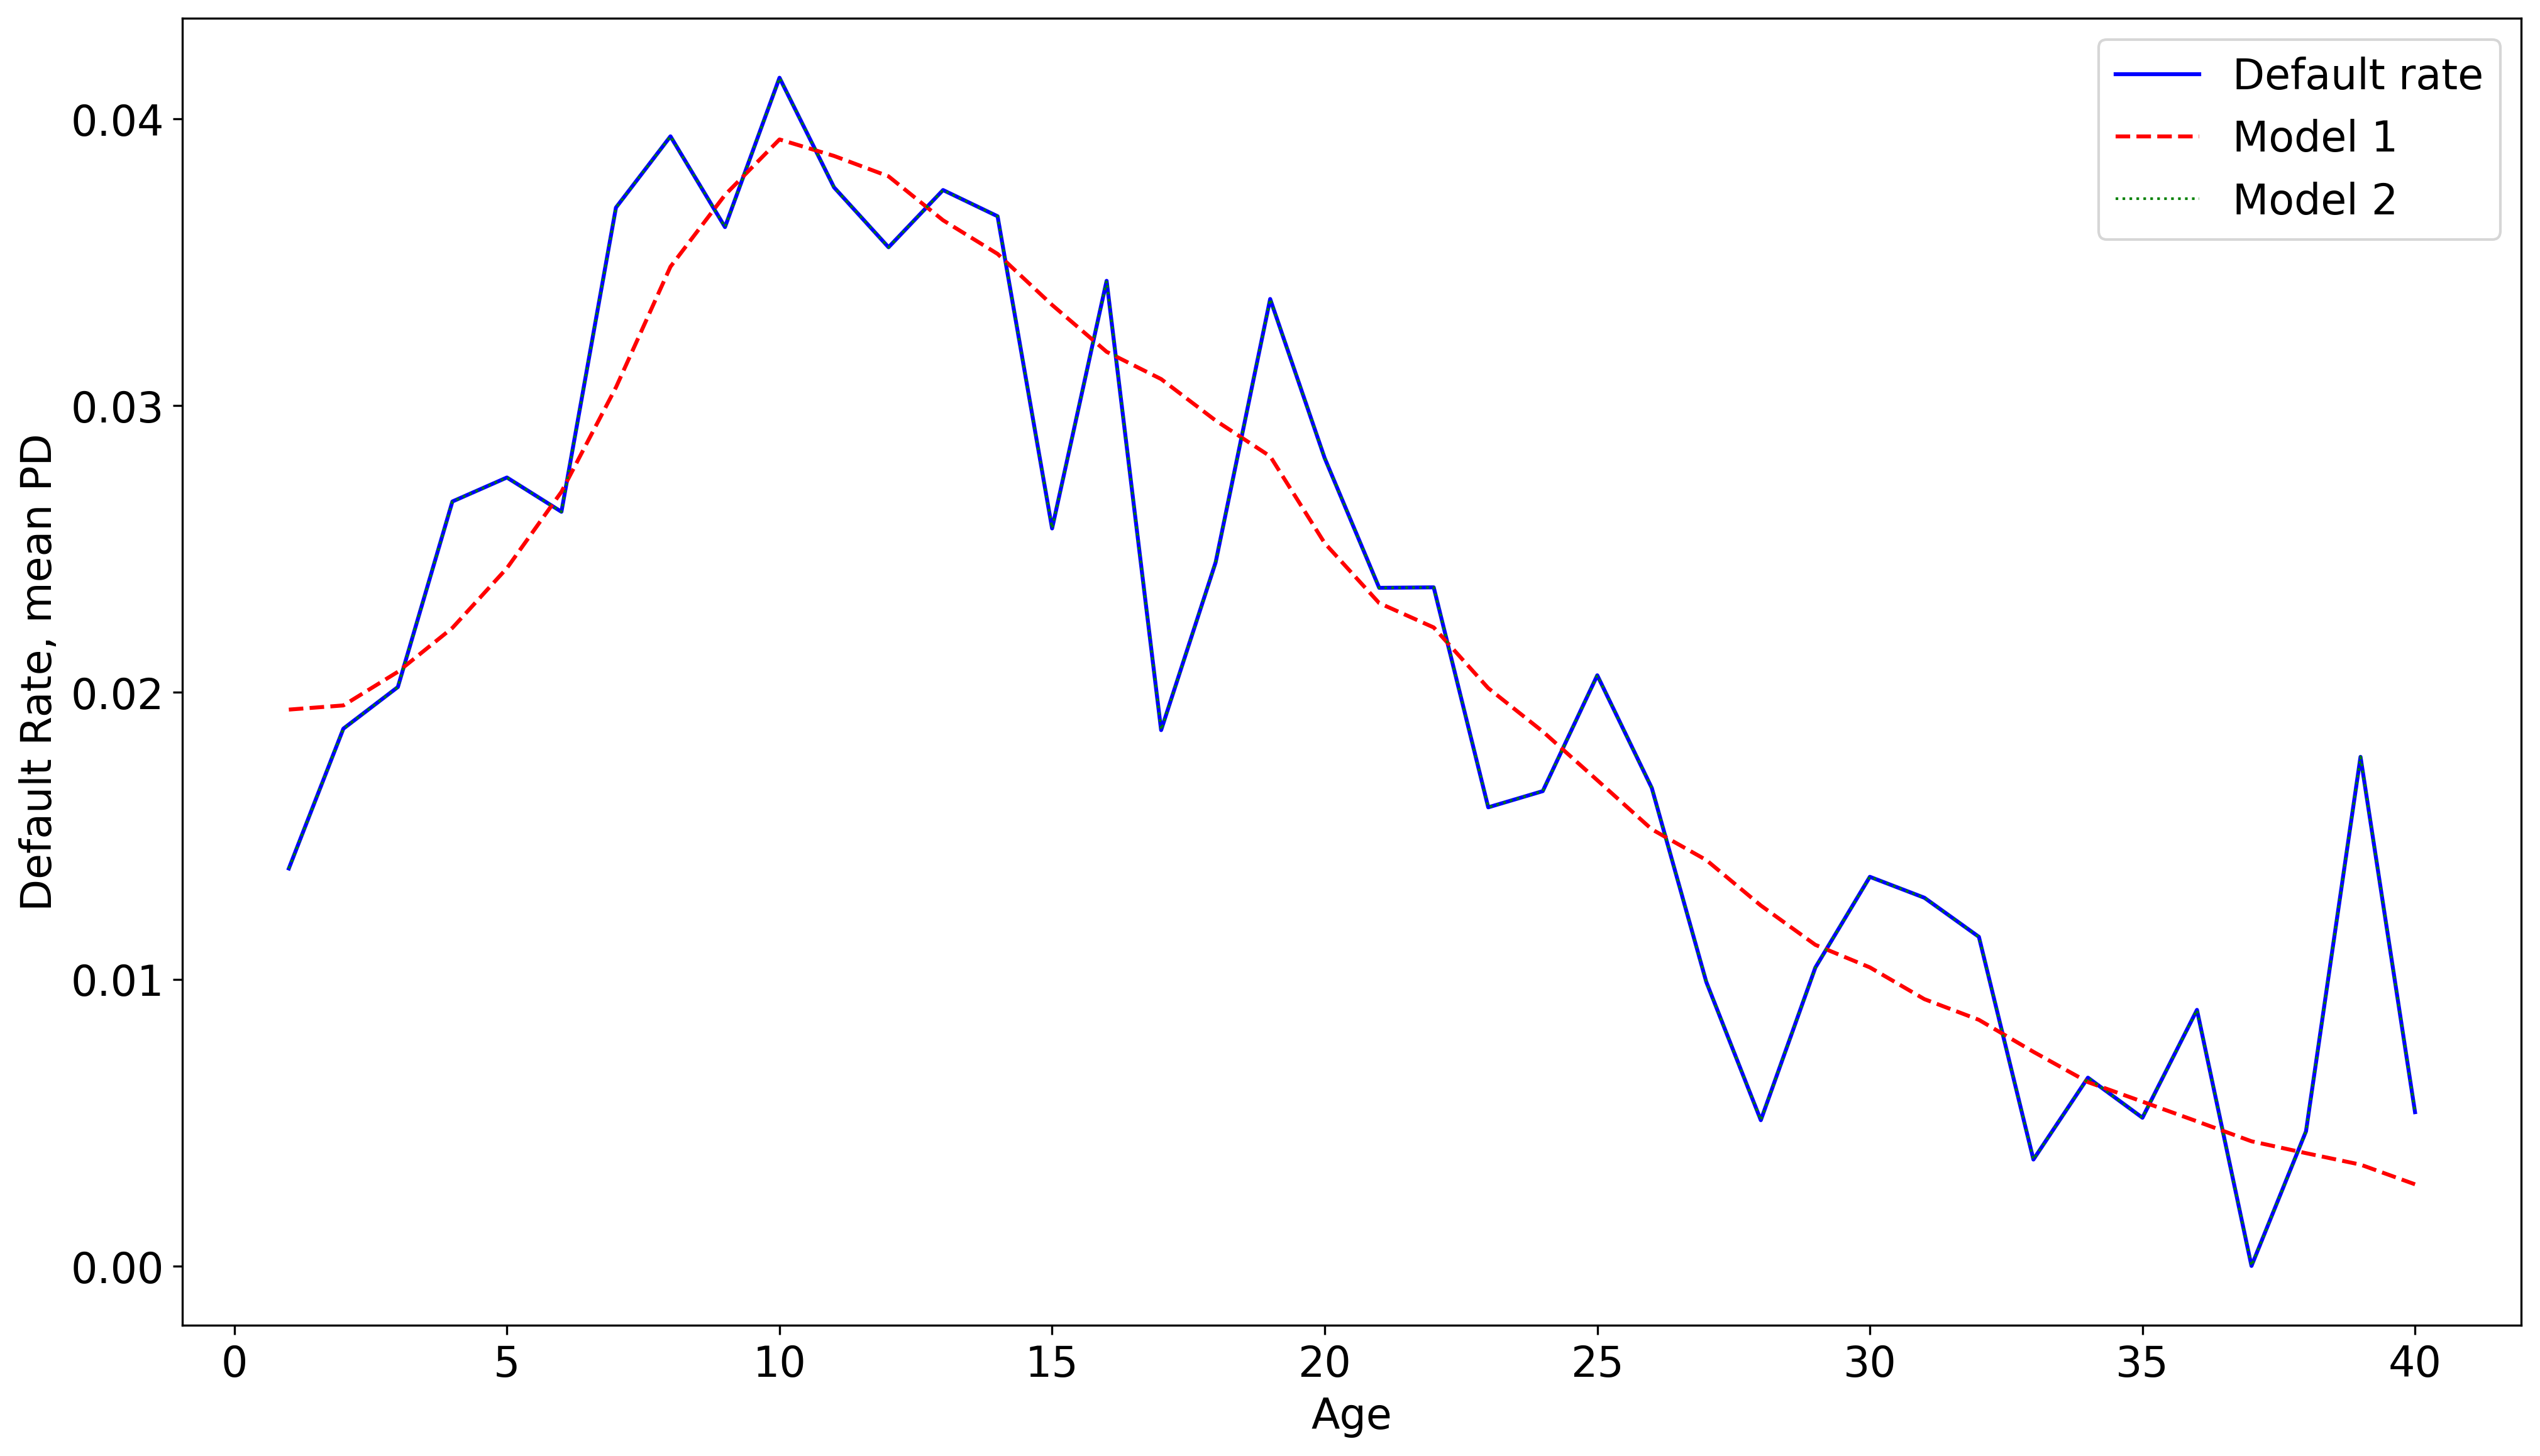

In [29]:
plt.plot('age', 'default_time', data=data4_mean_age, color='blue', label='Default rate')
plt.plot('age', 'PD_logit_model_1', data=data4_mean_age, color='red', label='Model 1', linestyle='dashed')
plt.plot('age', 'PD_logit_model_2', data=data4_mean_age, color='green', linewidth=1, label='Model 2', linestyle='dotted')
plt.xlabel('Age')
plt.ylabel('Default Rate, mean PD')
plt.legend(loc='best')
plt.show()

In [30]:
data2 = data.query('time == 60').copy()
data2.loc[:, 'TTM'] = data2.loc[:, 'mat_time'].subtract(data2.loc[:, 'time'])
data2 = data2.reset_index(drop=True)

print(len(data2))

771


In [31]:
data2 = data2.loc[data2.id.isin(
    [20442, 20444, 20445, 20446, 20447, 20450, 20451, 20452, 20453, 20454, 20455, 20456, 20457, 
     20458, 20459, 38839, 43763, 43765, 43766, 49709])]

In [32]:
data3 = data2.loc[np.repeat(data2.index.values, data2.TTM)]
data3 = data3.reset_index(drop=True)

In [33]:
data3.loc[:, 'time_tmp'] = data3.groupby(['id']).cumcount() + 1

data3.loc[:, 'age'] = data3.loc[:, 'time'] - data3.loc[:, 'orig_time'] + data3.loc[:, 'time_tmp']
data3.loc[:, 'age2'] = data3.loc[:, 'age'].multiply(data3.loc[:, 'age'])
data3.loc[:, 'time'] = data3.loc[:, 'time']+data3.loc[:, 'time_tmp']

data3 = data3.rename(columns={'TTM': 'TTM_0', 'balance_time' : 'balance_time_0'})
data3.loc[:, 'TTM'] = data3.loc[:, 'mat_time']-data3.loc[:, 'time']

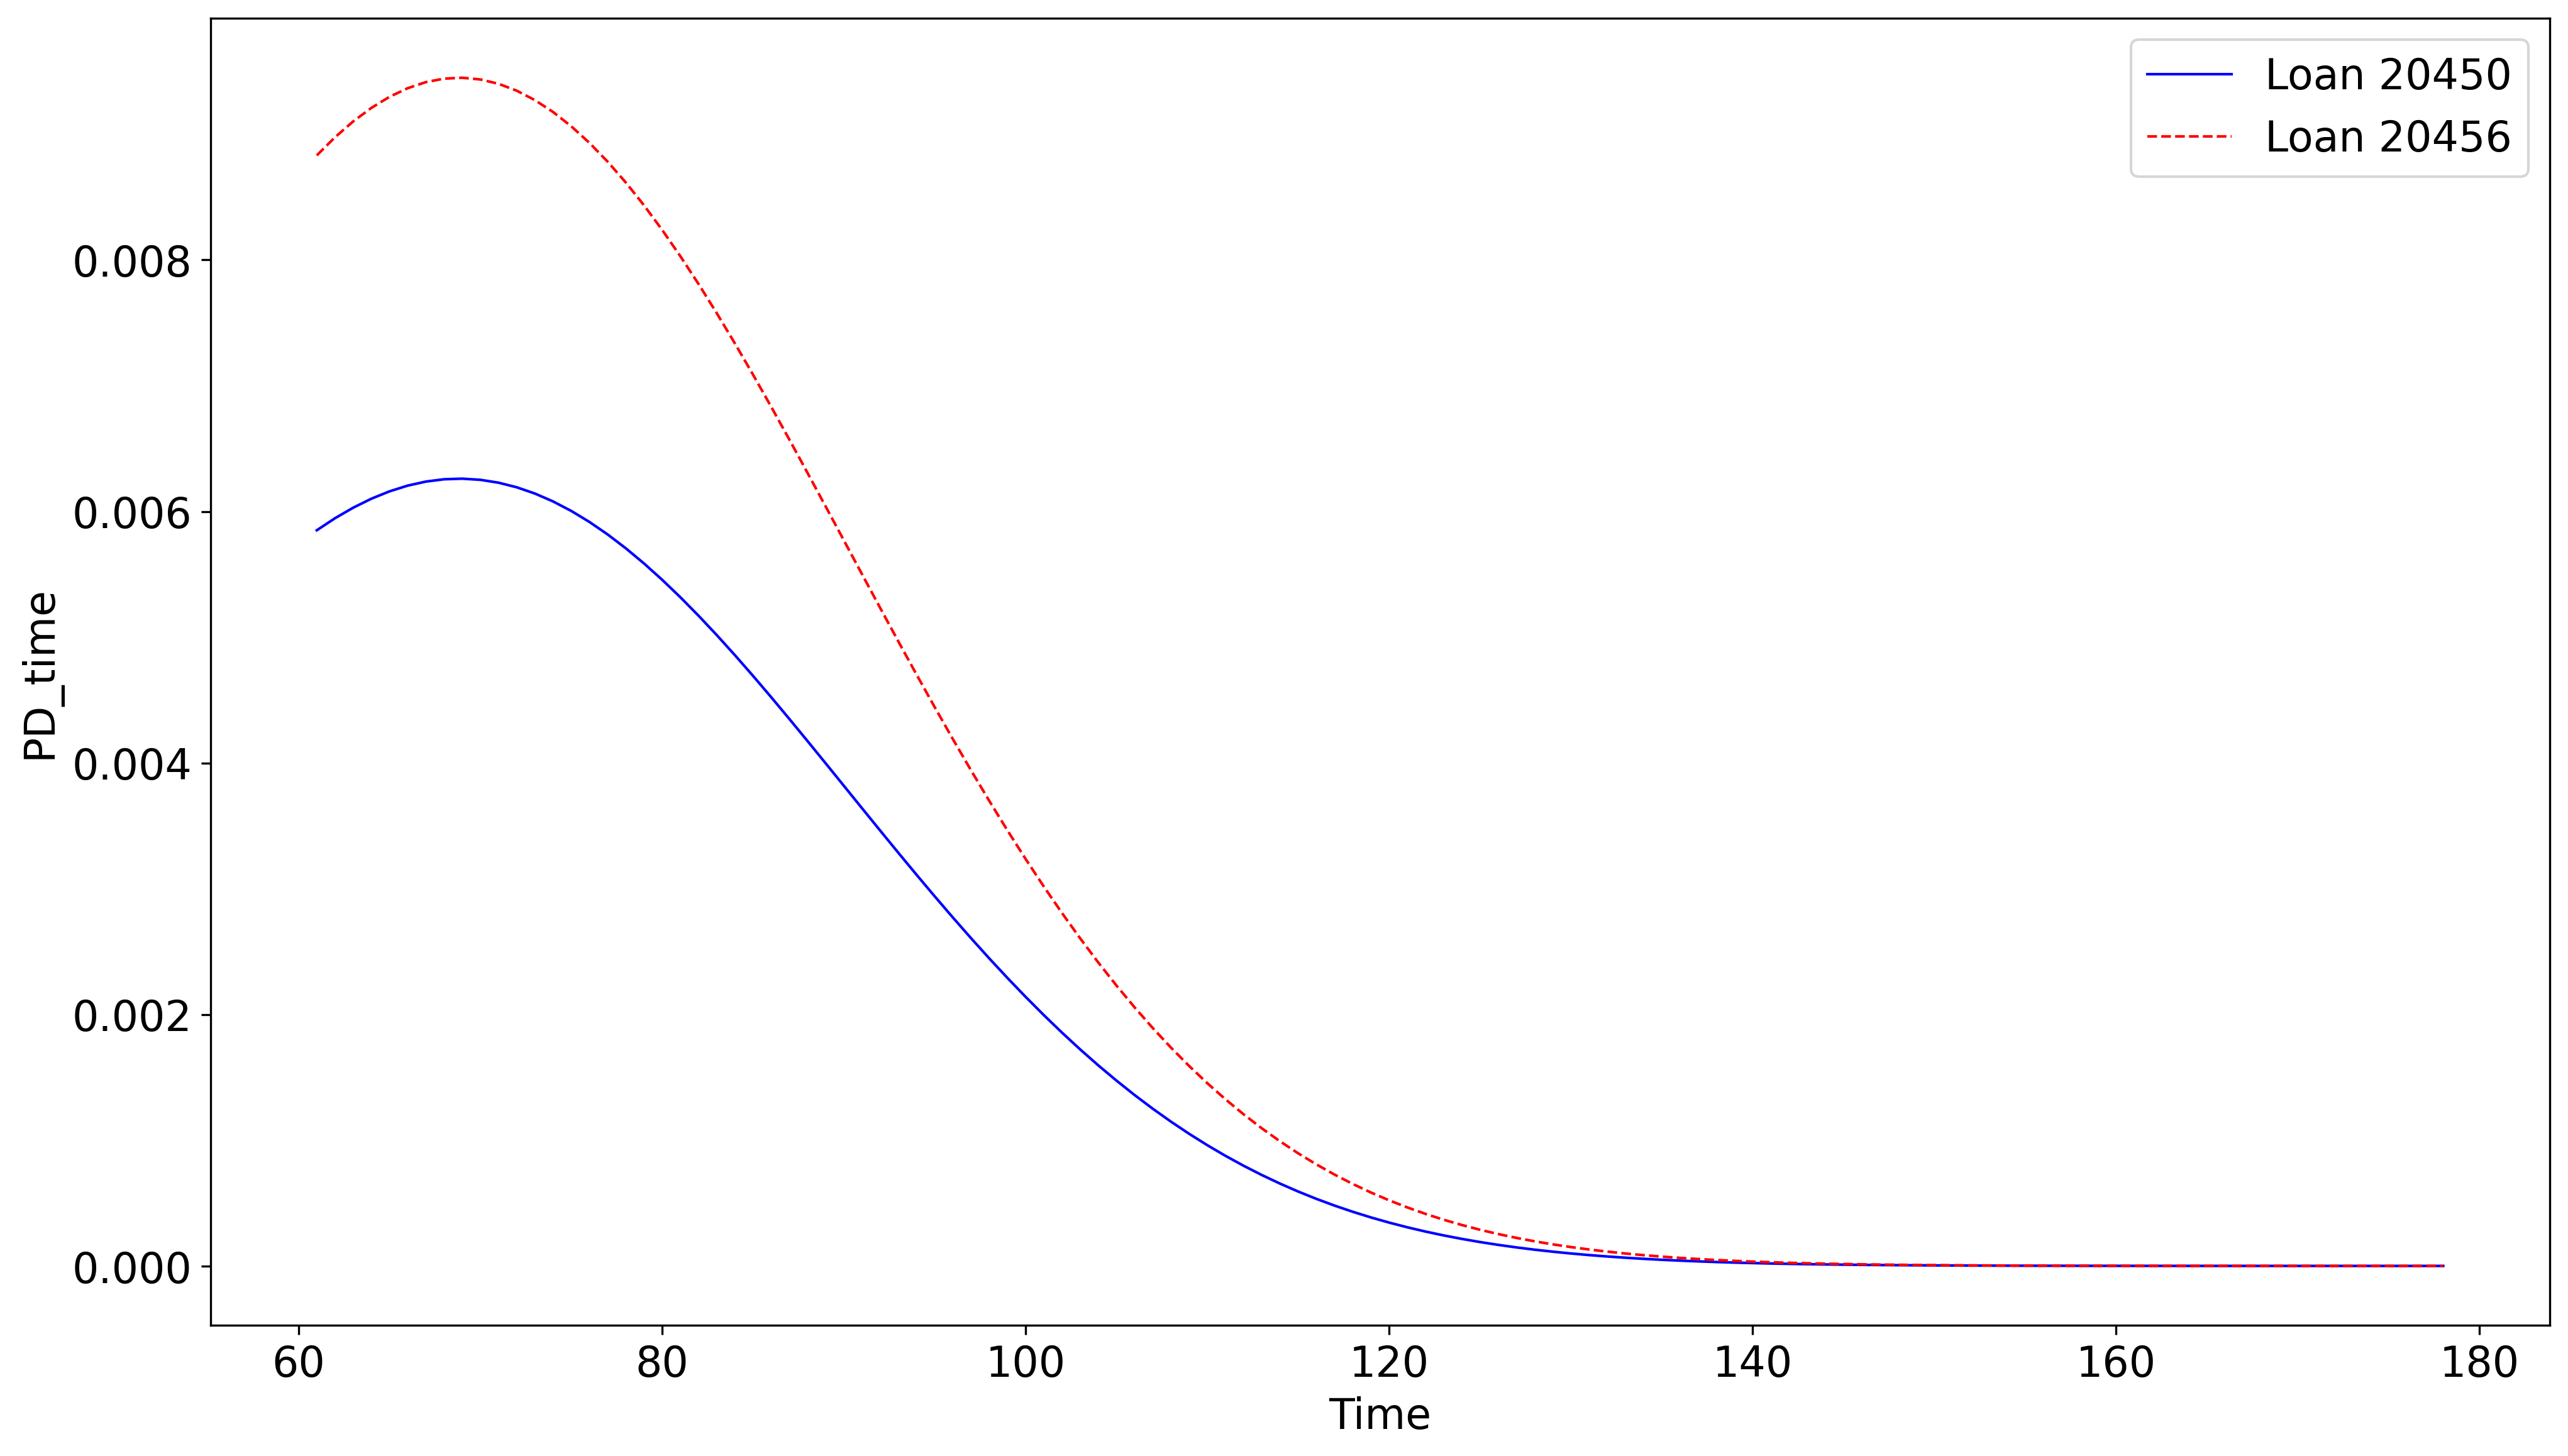

In [34]:
PD_time = pd.DataFrame(model_lr1.predict(data3), columns = ['PD_time'])
data3 = pd.concat([data3, PD_time], axis=1)

PD_time_20450 = data3.loc[data3.id == 20450, :]
PD_time_20456 = data3.loc[data3.id == 20456, :]

plt.plot('time', 'PD_time', data=PD_time_20450, marker='', color='blue', linewidth=1, label='Loan 20450')
plt.plot('time', 'PD_time', data=PD_time_20456, marker='', color='red', linewidth=1, label='Loan 20456', linestyle='dashed')

plt.xlabel('Time')
plt.ylabel('PD_time')
plt.legend(loc='best')
plt.show()

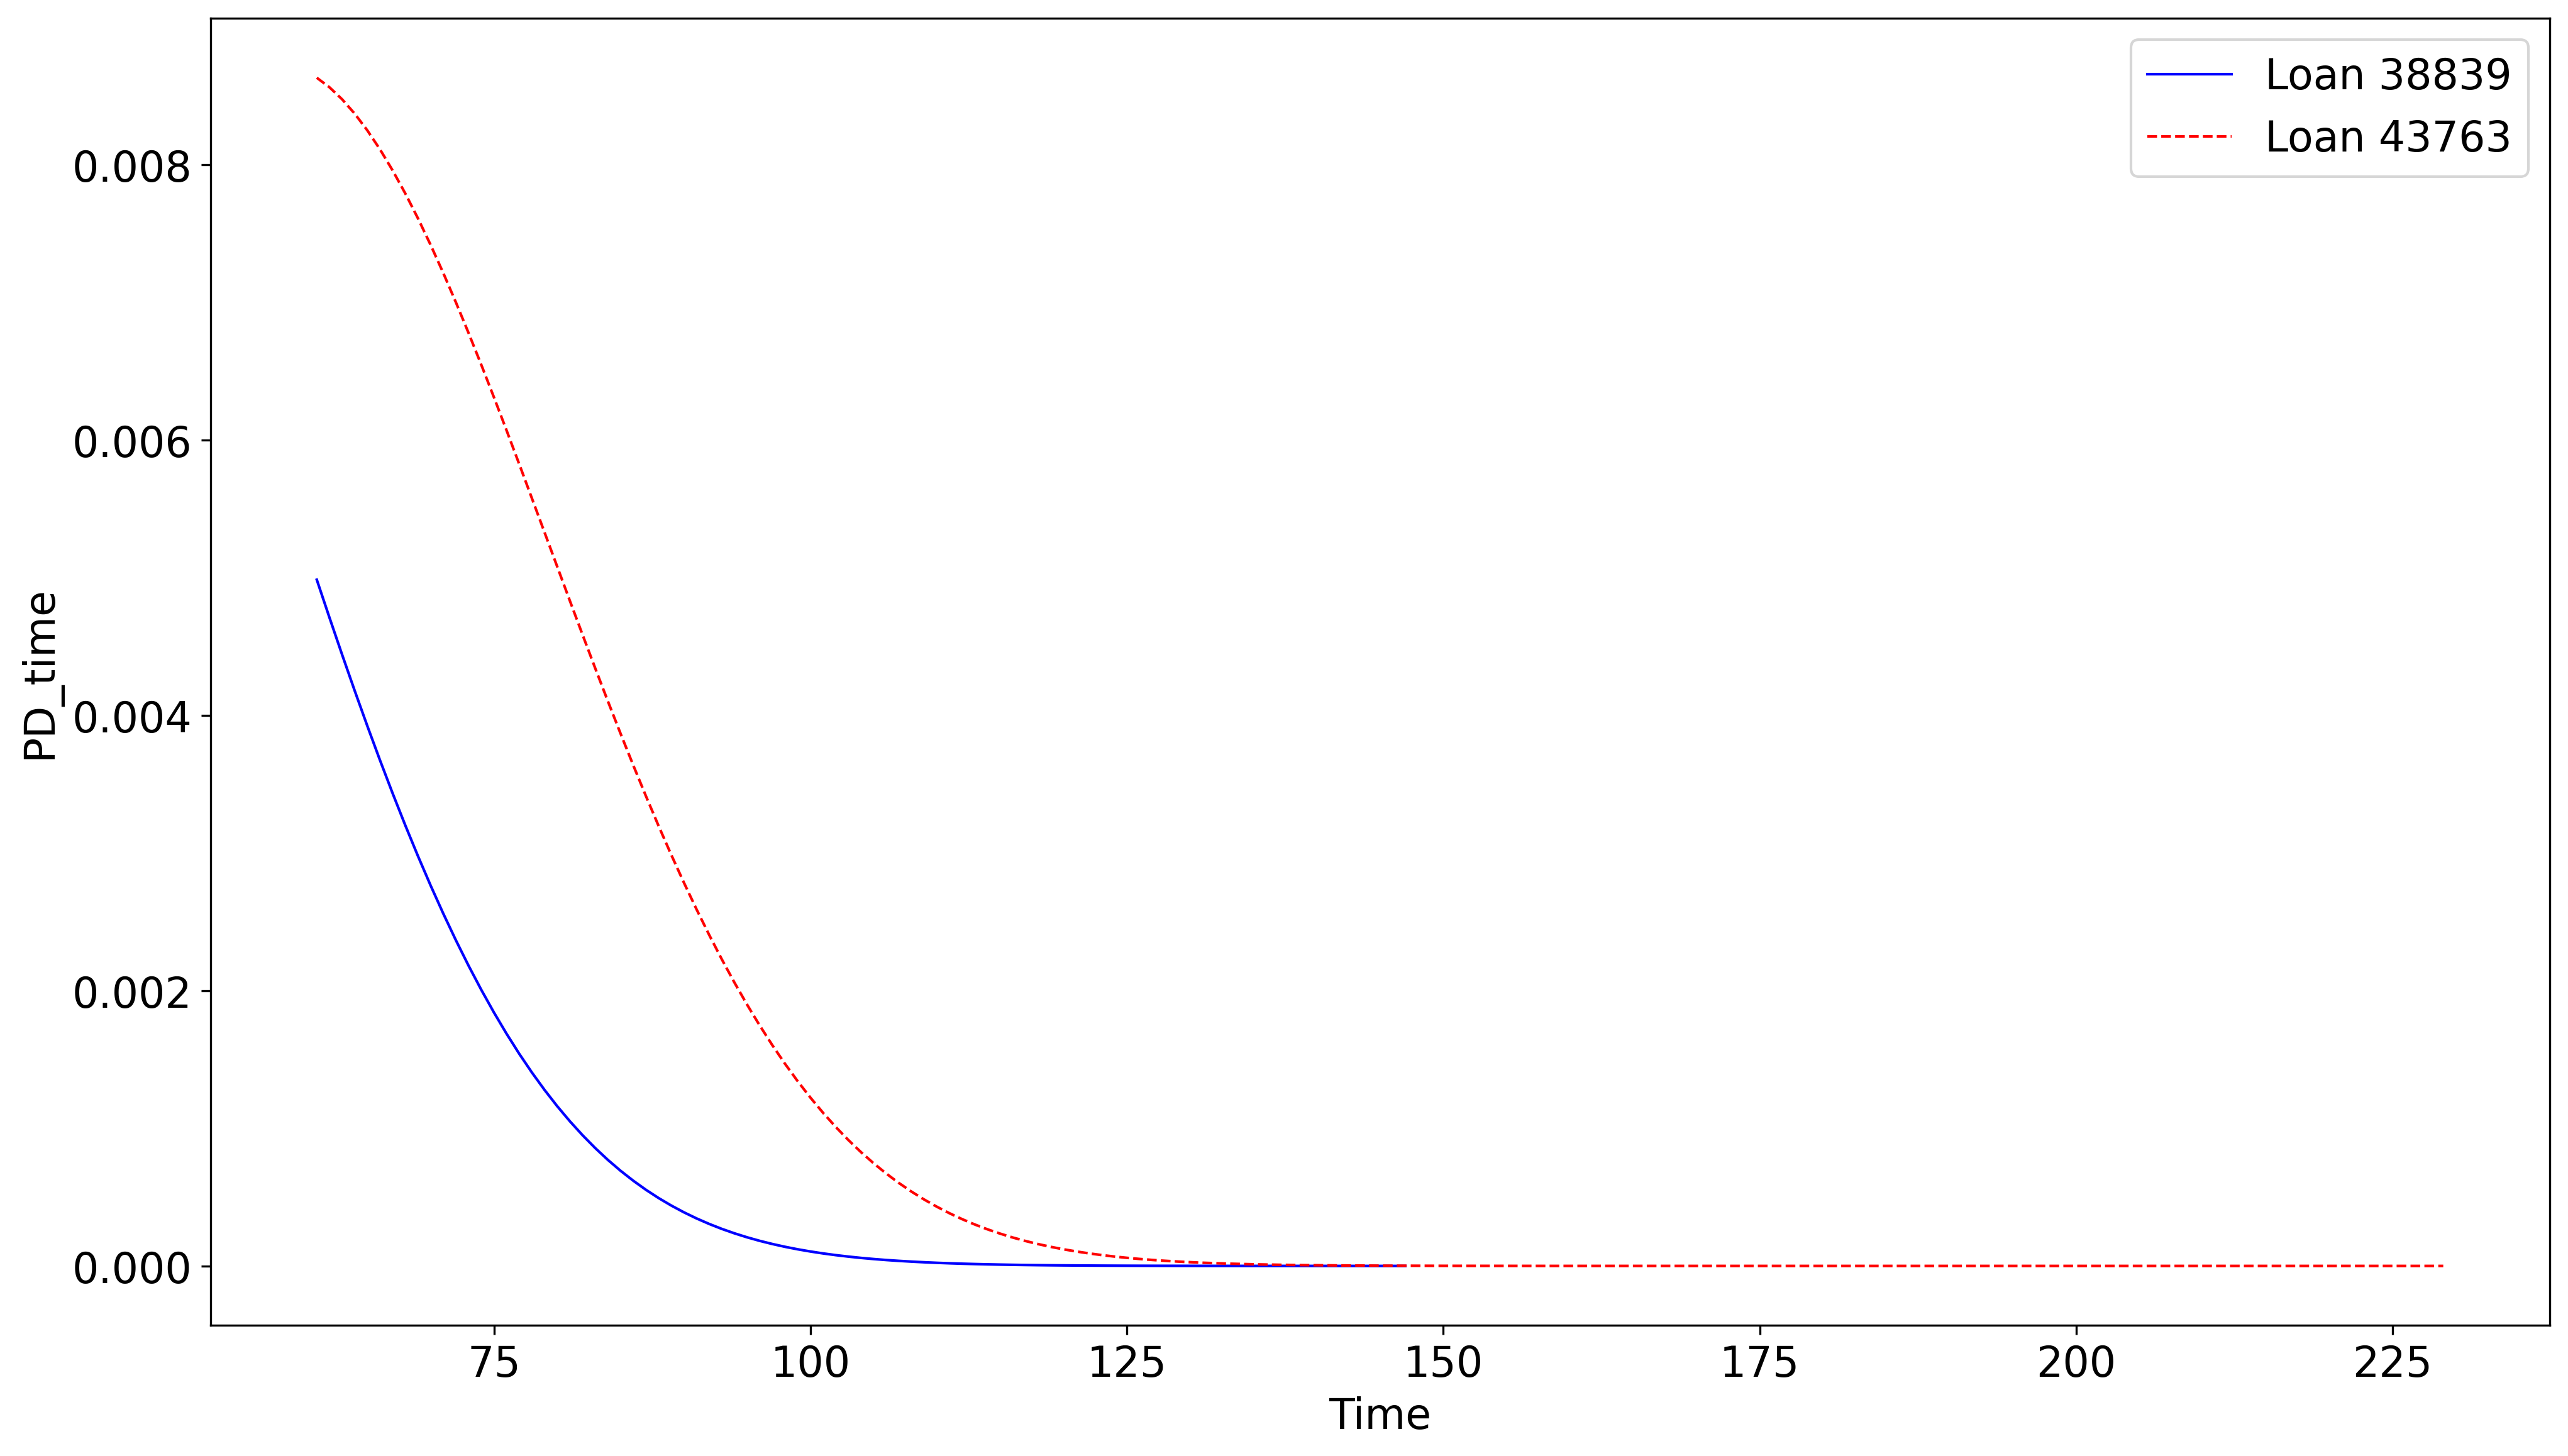

In [35]:
PD_time_38839 = data3.loc[data3.id == 38839, :]
PD_time_43763 = data3.loc[data3.id == 43763, :]

plt.plot('time', 'PD_time', data=PD_time_38839, marker='', color='blue', linewidth=1, label='Loan 38839')
plt.plot('time', 'PD_time', data=PD_time_43763, marker='', color='red', linewidth=1, label='Loan 43763', linestyle='dashed')

plt.xlabel('Time')
plt.ylabel('PD_time')
plt.legend(loc='best')
plt.show()

In [37]:
data.loc[:, 'indicator'] = 0
data.loc[:, 'equity_orig_time'] = 100 - data['LTV_orig_time']

data.sort_values(['id', 'age'], ascending=True, inplace=True)
data = data.reset_index(drop=True)
ref = np.array(np.where([data.id.duplicated(keep='last')==False]))[1]
data.loc[ref, 'indicator'] = 1

data2 = data[(data.indicator==1) | (data.default_time == 1)].copy()
ref = np.where(data2.id.duplicated(keep='first')==False)[0]

data_cross = data2.iloc[ref].copy()

In [41]:
print(data_cross.loc[(data_cross.id==9) | (data_cross.id==47) | (data_cross.id==4), ['id', 'time', 'first_time', 'age', 'default_time', 'payoff_time']])

      id  time  first_time   age  default_time  payoff_time
34   4.0  60.0        25.0  36.0           0.0          0.0
47   9.0  37.0        25.0  13.0           1.0          0.0
65  47.0  27.0        25.0   3.0           0.0          1.0


In [45]:
model_cph = CoxPHFitter()

cols = ['FICO_orig_time', 'equity_orig_time', 'age', 'default_time']
model_cph.fit(data_cross[cols].dropna(), 'age', event_col='default_time')

print(model_cph.summary)

                      coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                         
FICO_orig_time   -0.004349   0.995660  0.000362       -0.005058   
equity_orig_time -0.020588   0.979622  0.002619       -0.025722   

                  coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                    
FICO_orig_time         -0.003641             0.994955             0.996366   
equity_orig_time       -0.015455             0.974606             0.984664   

                  cmp to          z             p    -log2(p)  
covariate                                                      
FICO_orig_time       0.0 -12.029338  2.491506e-33  108.306609  
equity_orig_time     0.0  -7.860493  3.826245e-15   47.892992  


In [46]:
hazard = model_cph.baseline_hazard_.reset_index(drop=False).rename({'index':'age', 'baseline hazard':'baseline'}, axis='columns')

borrower_data = pd.DataFrame({'FICO_orig_time':[400], 'equity_orig_time':[20]})

partial = model_cph.predict_partial_hazard(borrower_data).values
hazard['borrower'] = hazard.baseline * partial

hazard['logbaseline'] = np.log(hazard.baseline)
hazard['logborrower'] = np.log(hazard.borrower)

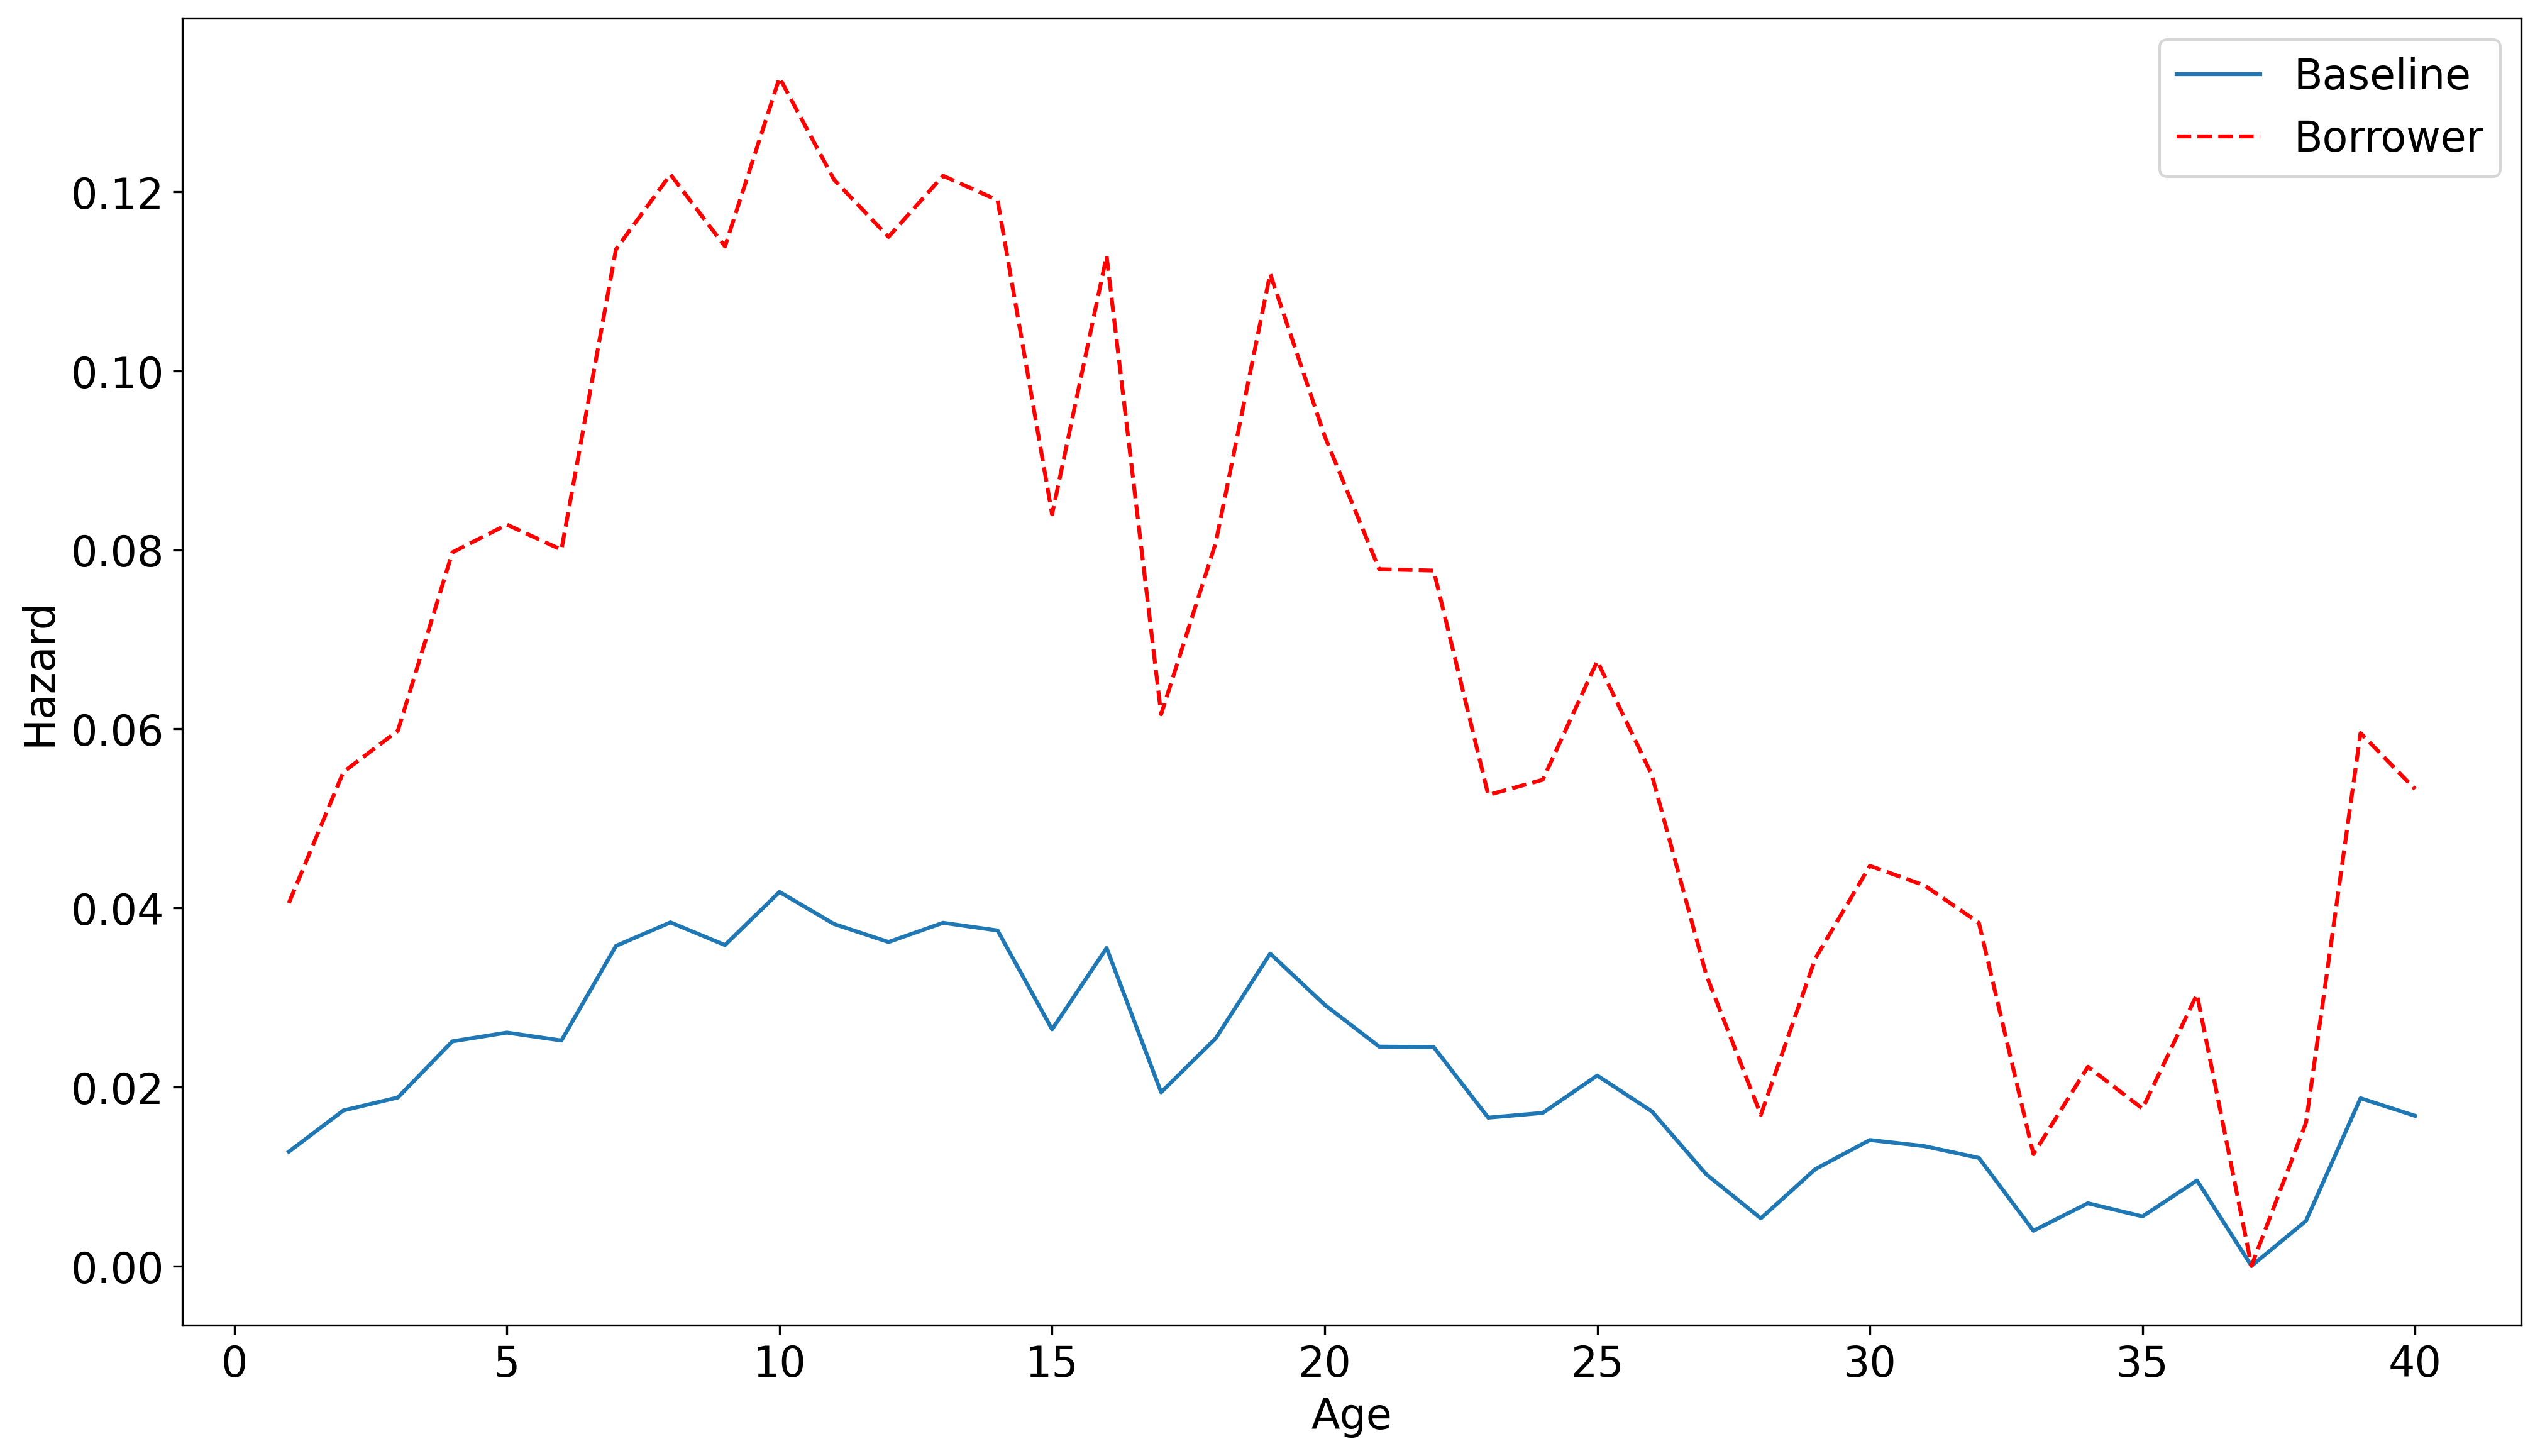

In [47]:
plt.plot('age', 'baseline', data=hazard, label='Baseline')
plt.plot('age', 'borrower', data=hazard, color='red', label='Borrower', linestyle='dashed')
plt.xlabel('Age')
plt.ylabel('Hazard')
plt.legend(loc='best')
plt.show()

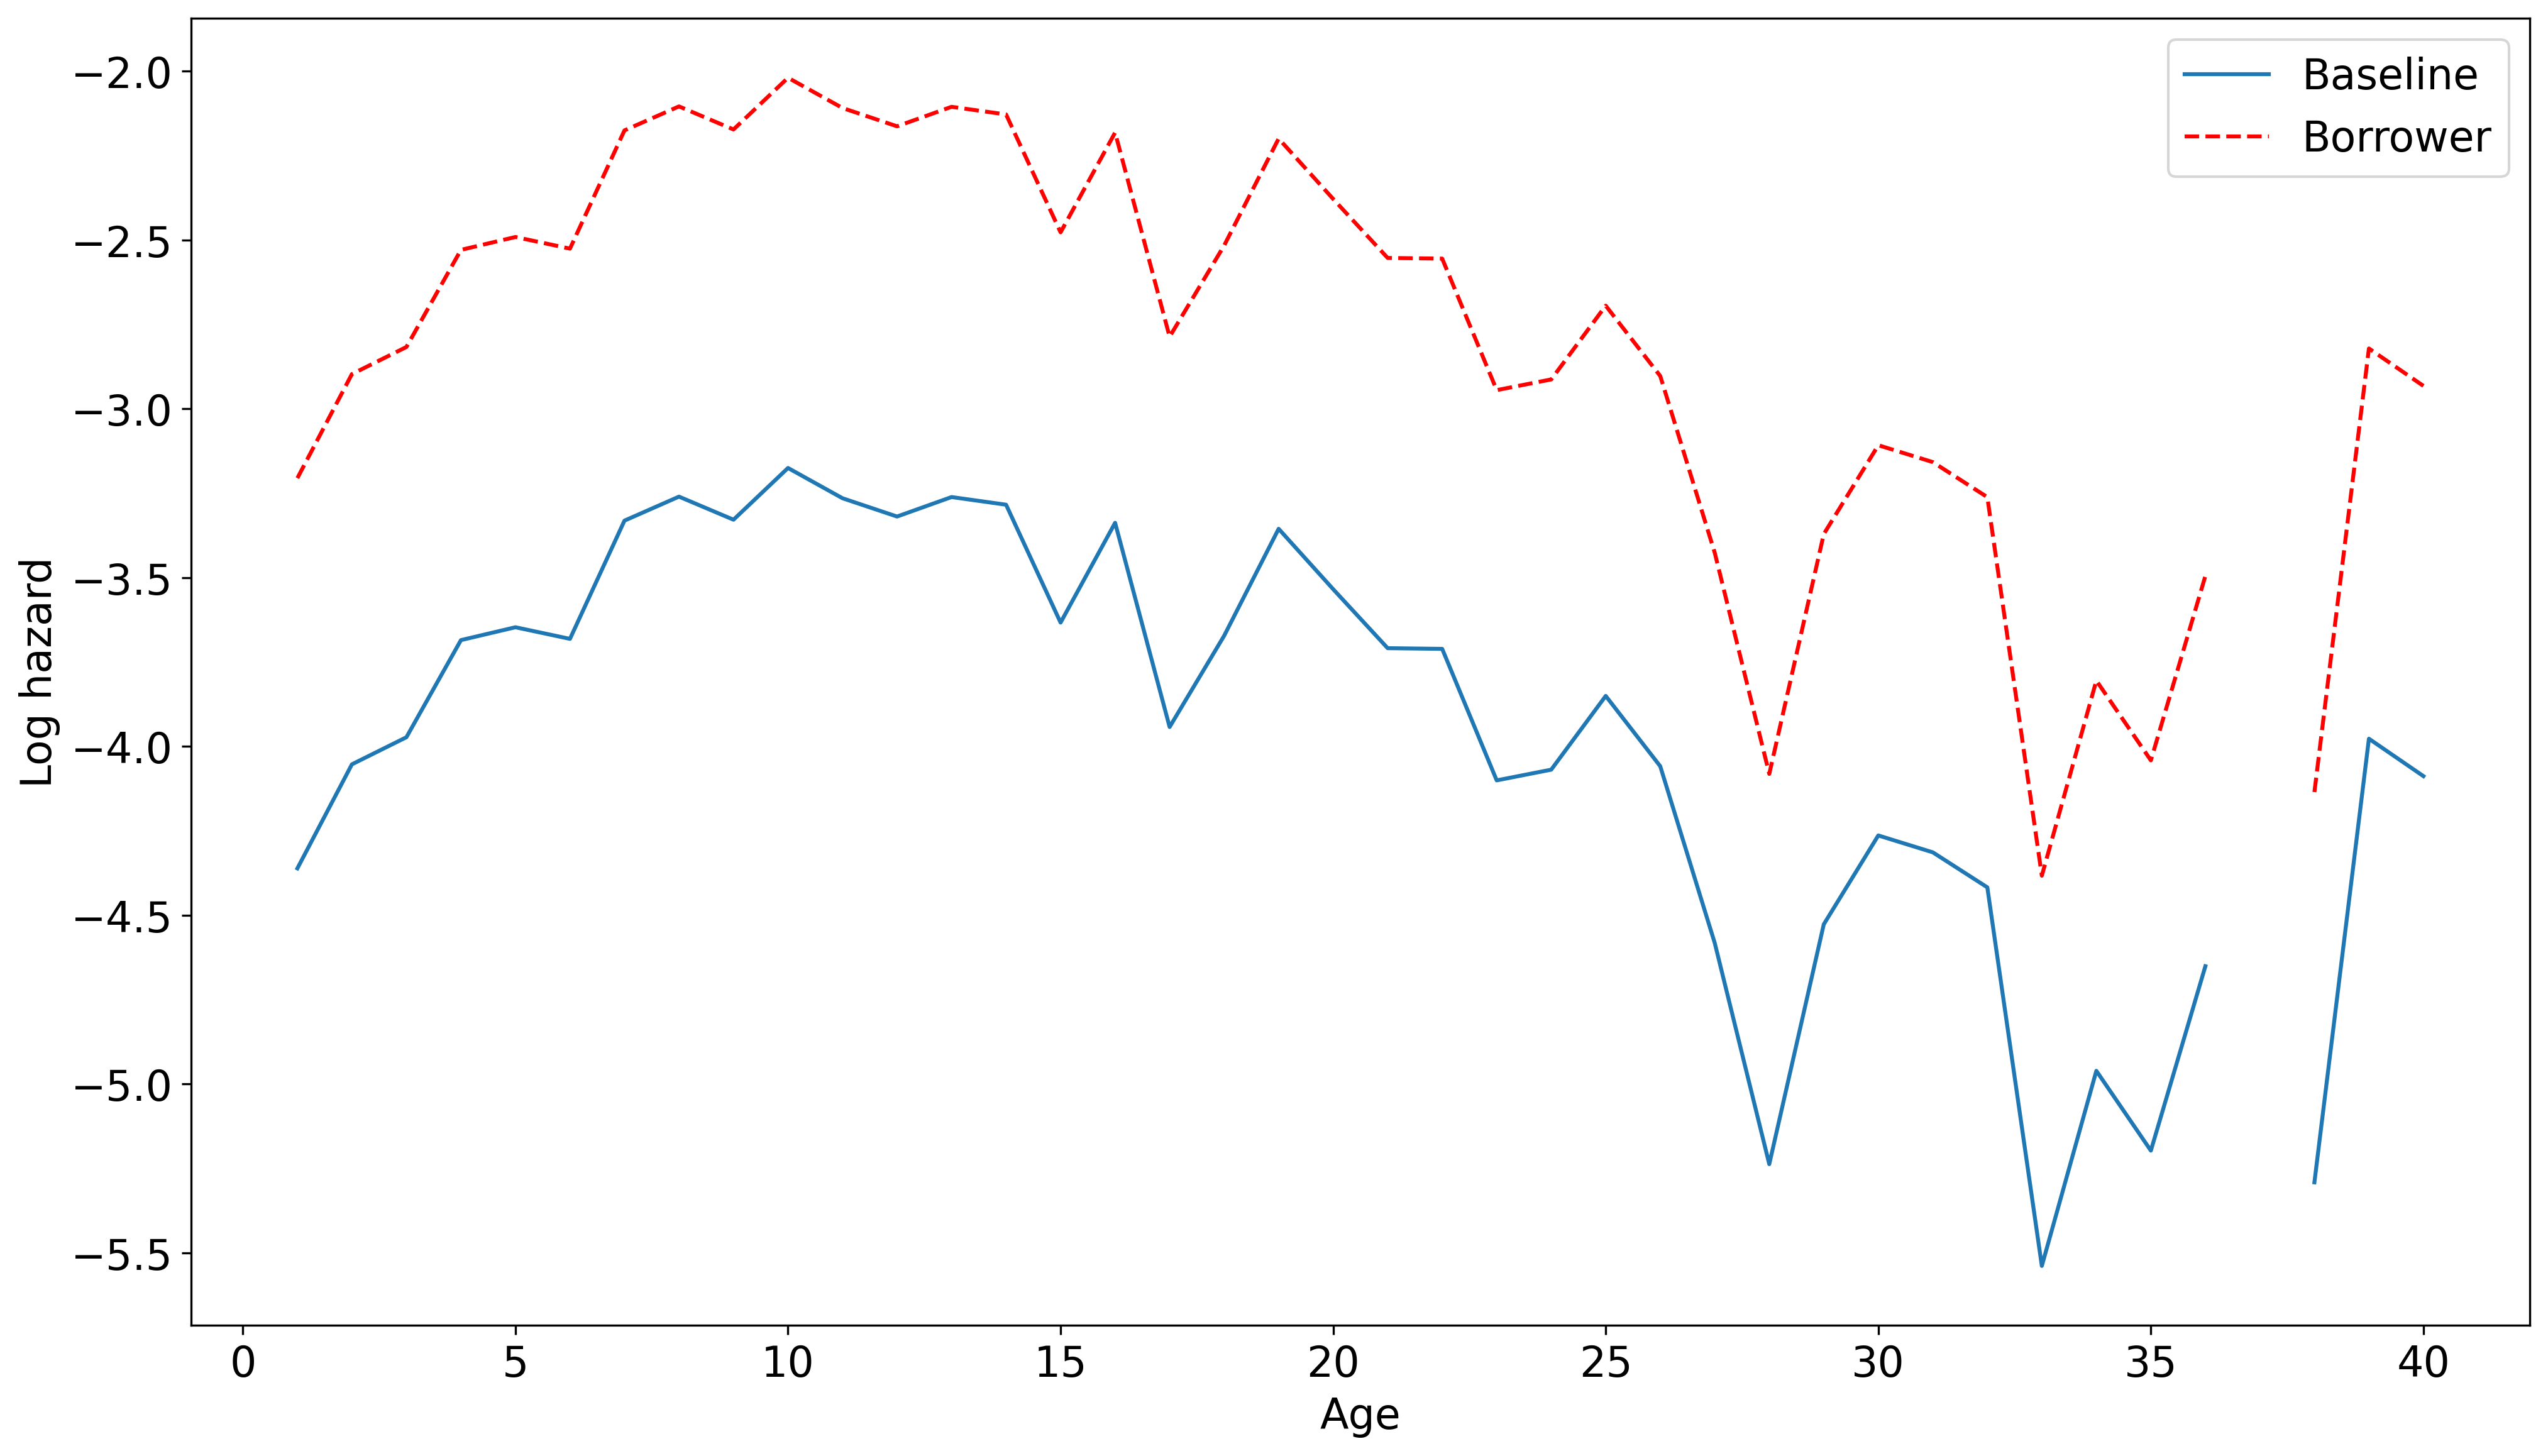

In [48]:
plt.plot('age', 'logbaseline', data=hazard, label='Baseline')
plt.plot('age', 'logborrower', data=hazard, color='red', linestyle='dashed', label='Borrower')
plt.xlabel('Age')
plt.ylabel('Log hazard')
plt.legend(loc='best')
plt.show()

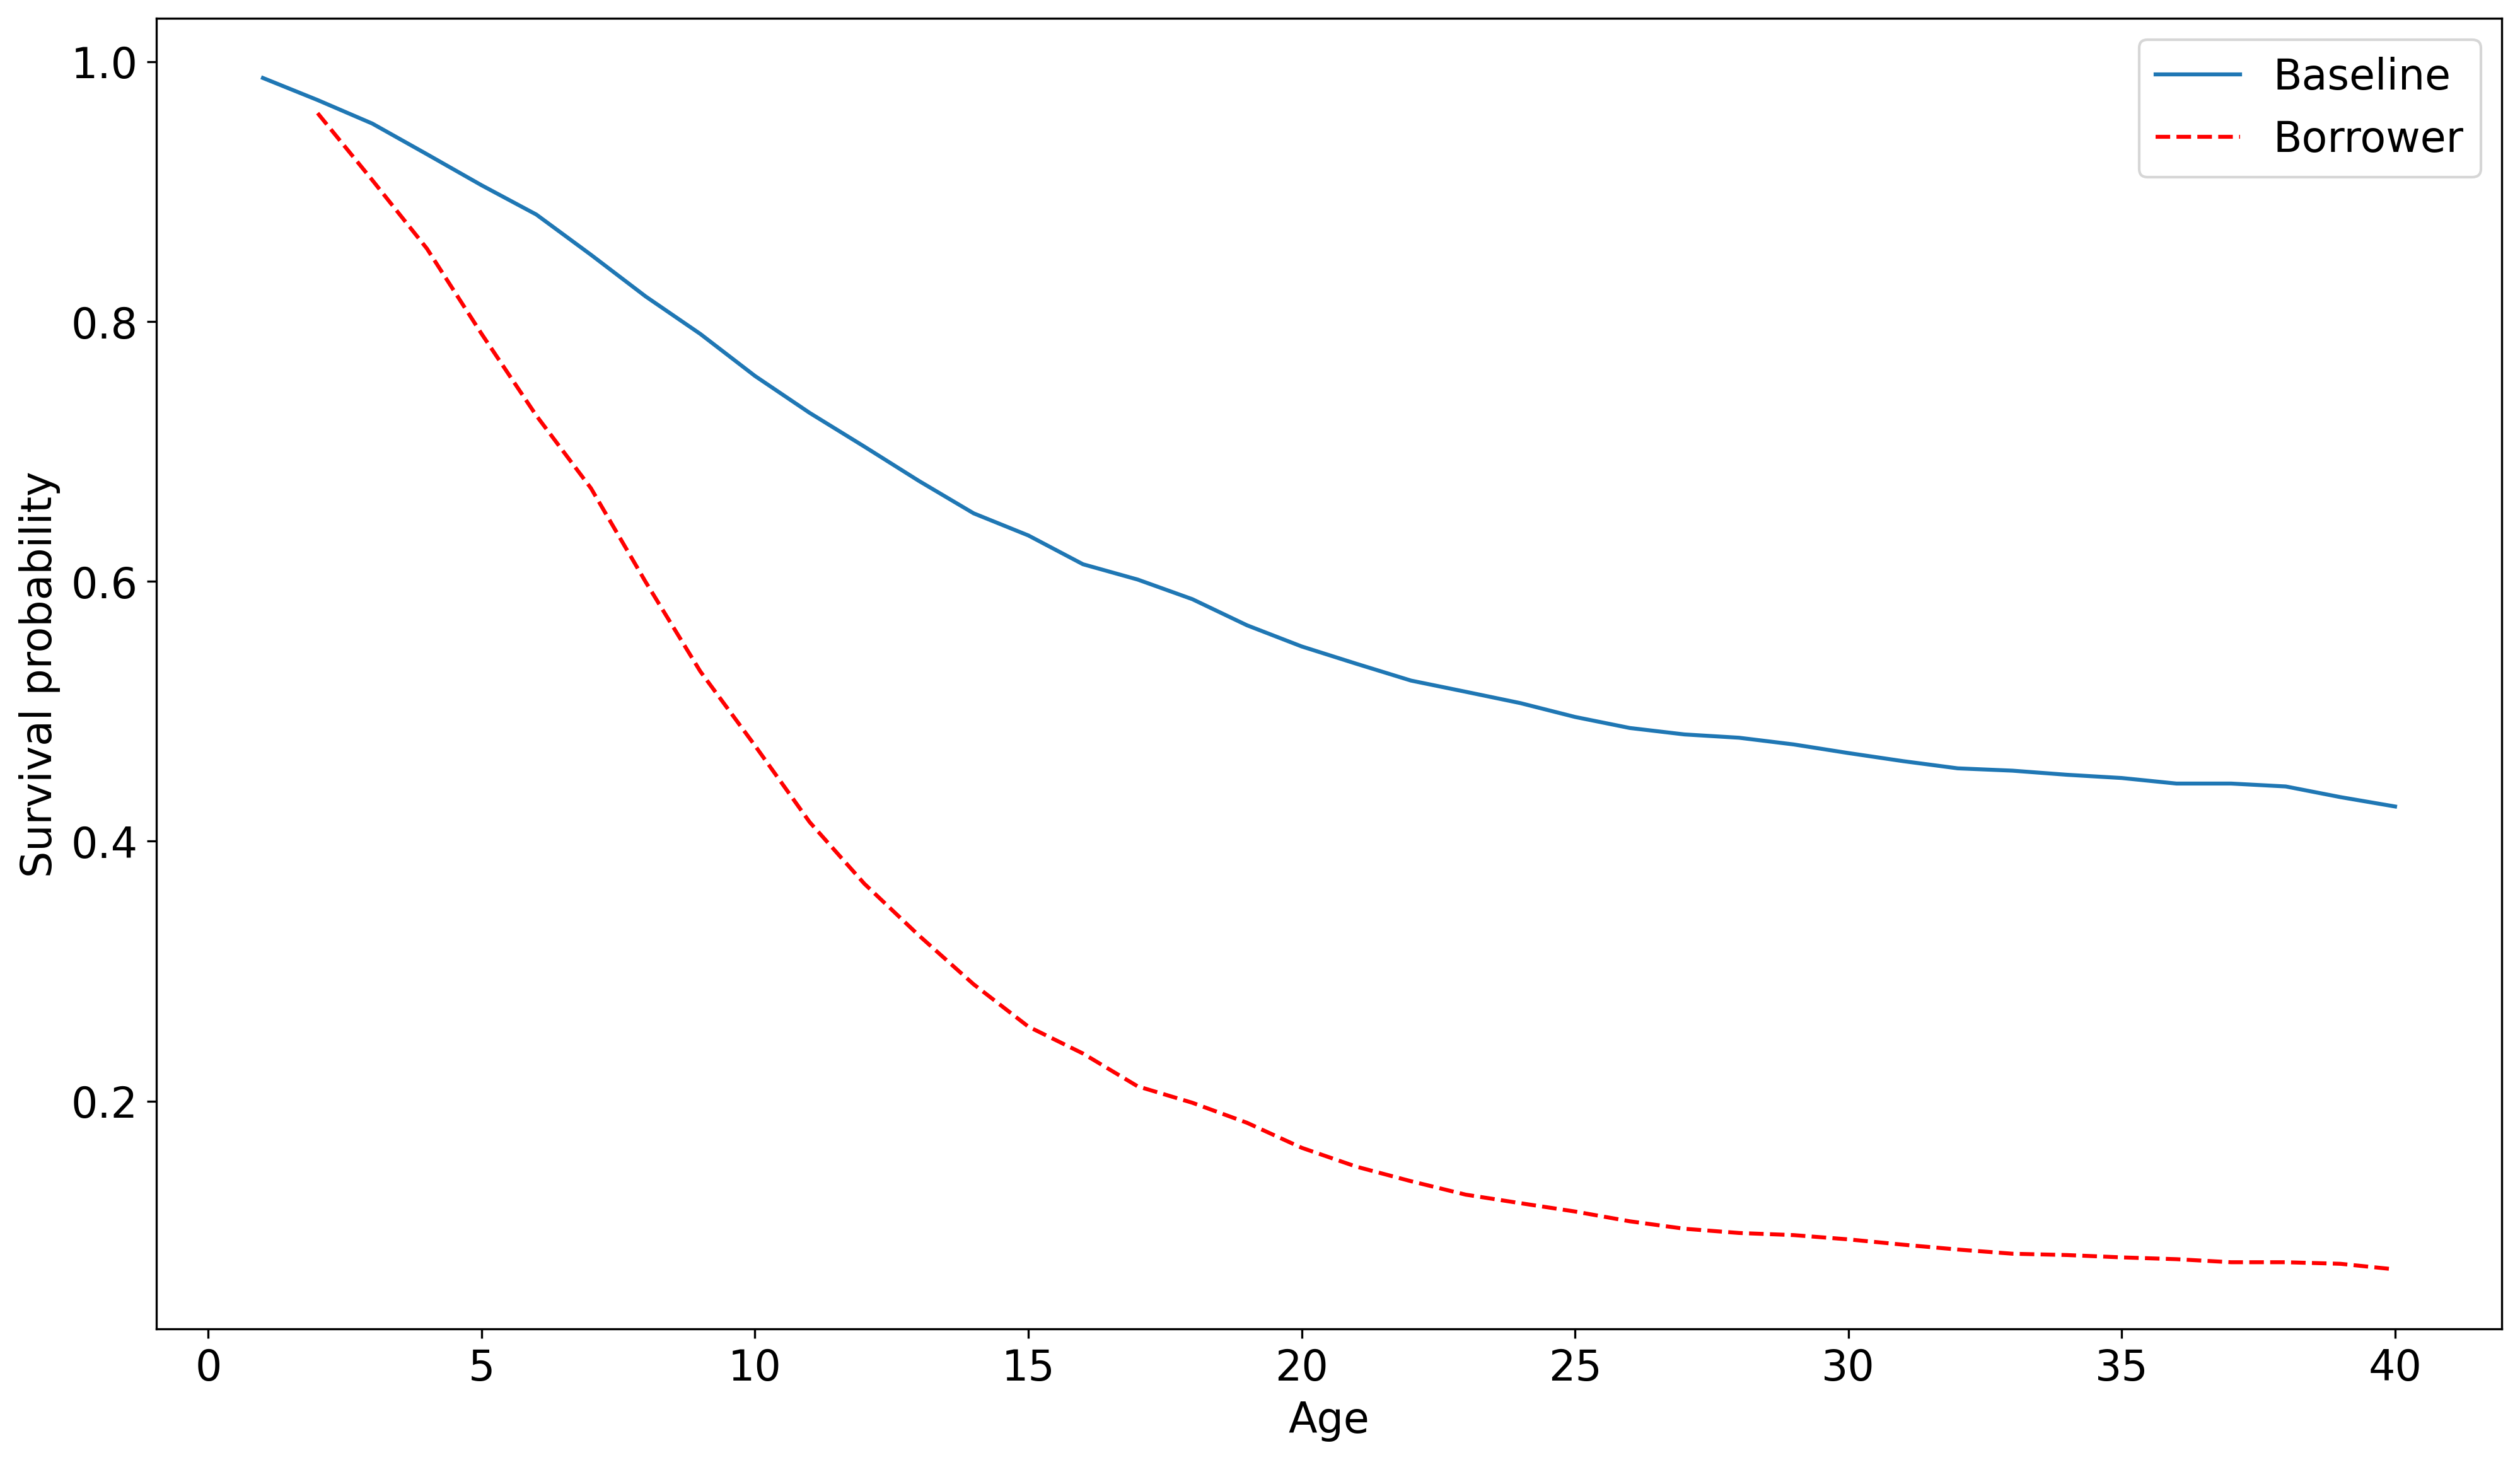

In [49]:
survival = model_cph.baseline_survival_.reset_index(drop=False).rename({'index':'age', 'baseline survival':'baseline'}, axis='columns')

survival['borrower'] = model_cph.predict_survival_function(borrower_data)

plt.plot('age', 'baseline', data=survival, label='Baseline')
plt.plot('age', 'borrower', data=survival, color='red', label='Borrower', linestyle='dashed')
plt.xlabel('Age')
plt.ylabel('Survival probability')
plt.legend(loc='best')
plt.show()

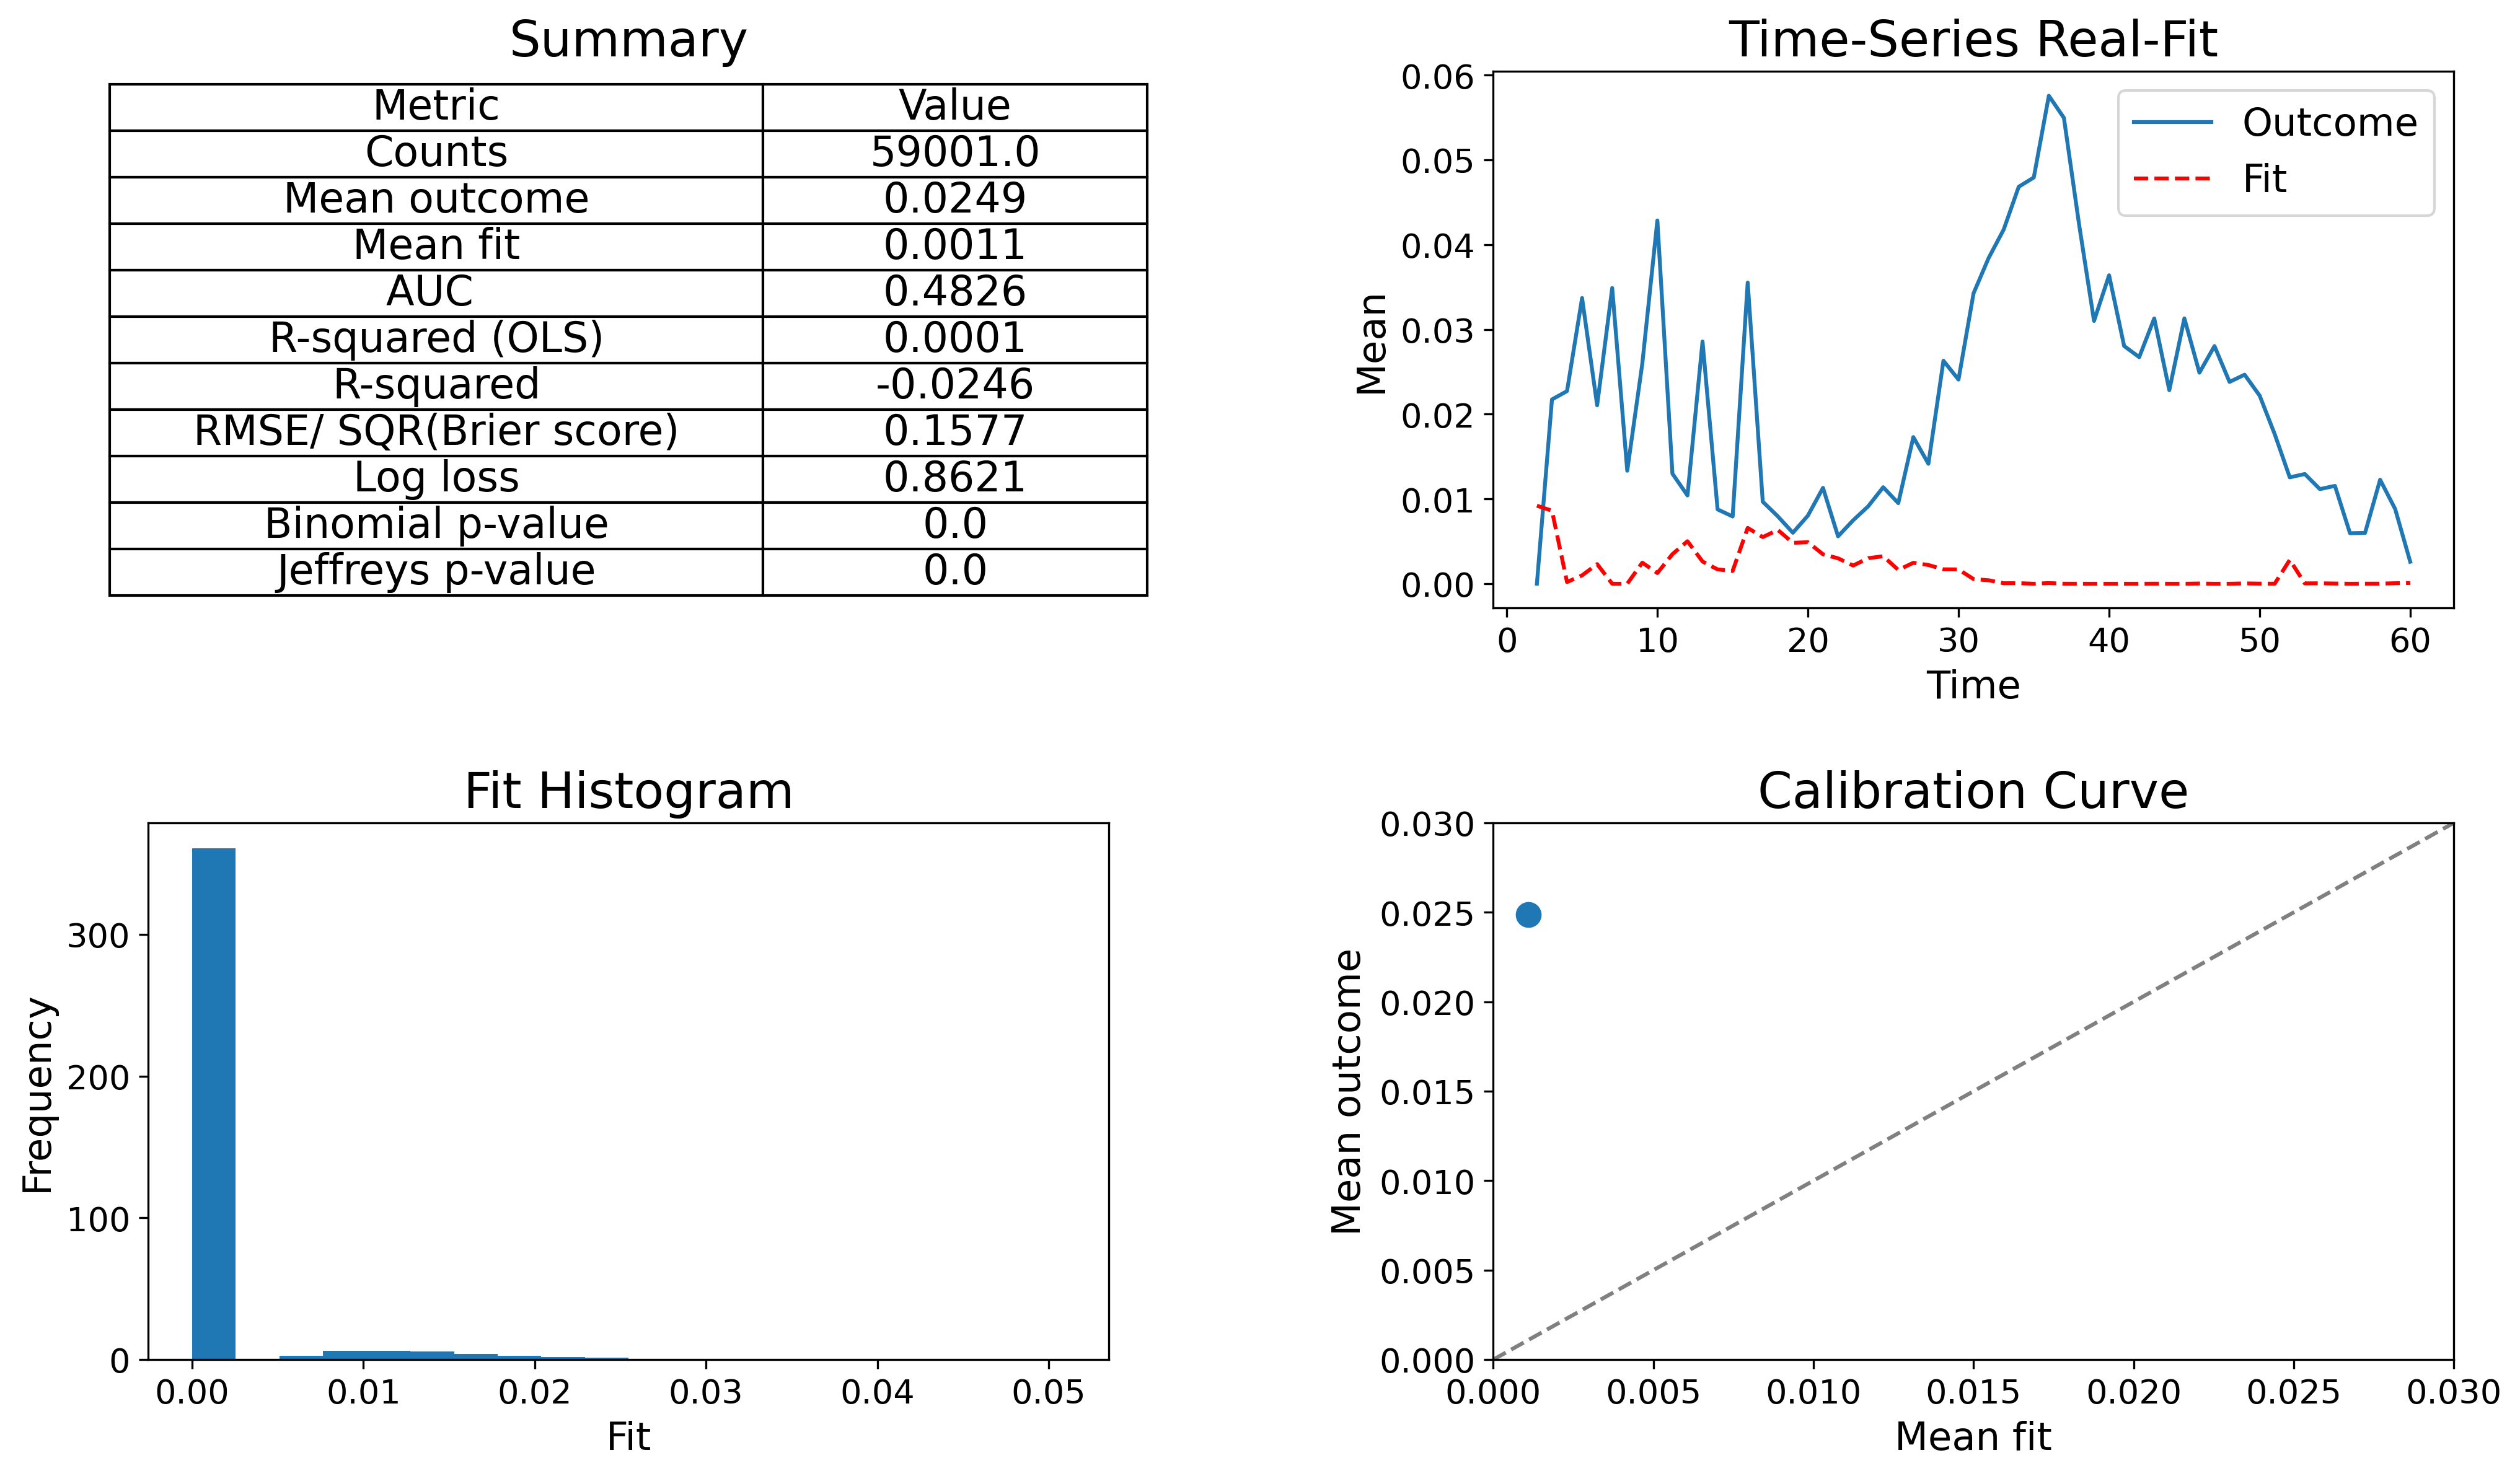

In [52]:
survival = model_cph.predict_survival_function(data[['FICO_orig_time', 'equity_orig_time', 'age', 'default_time']].dropna()).transpose()

survival = survival.reset_index(drop=True)
data3 = data.reset_index(drop=True).join(survival)

s1_indices = data3['age_1f'].astype(int)
s2_indices = data3['age_1'].astype(int)

data3['S1'] = survival.to_numpy()[np.arange(len(survival)), s1_indices]
data3.loc[data3.age_1 == 0, 'S1'] = 1
data3['S2'] = survival.to_numpy()[np.arange(len(survival)), s2_indices]

data3['PD_time'] = (data3['S1'] - data3['S2']) / data3['S1']

validation(data3['PD_time'], data3['default_time'], data3['time'])

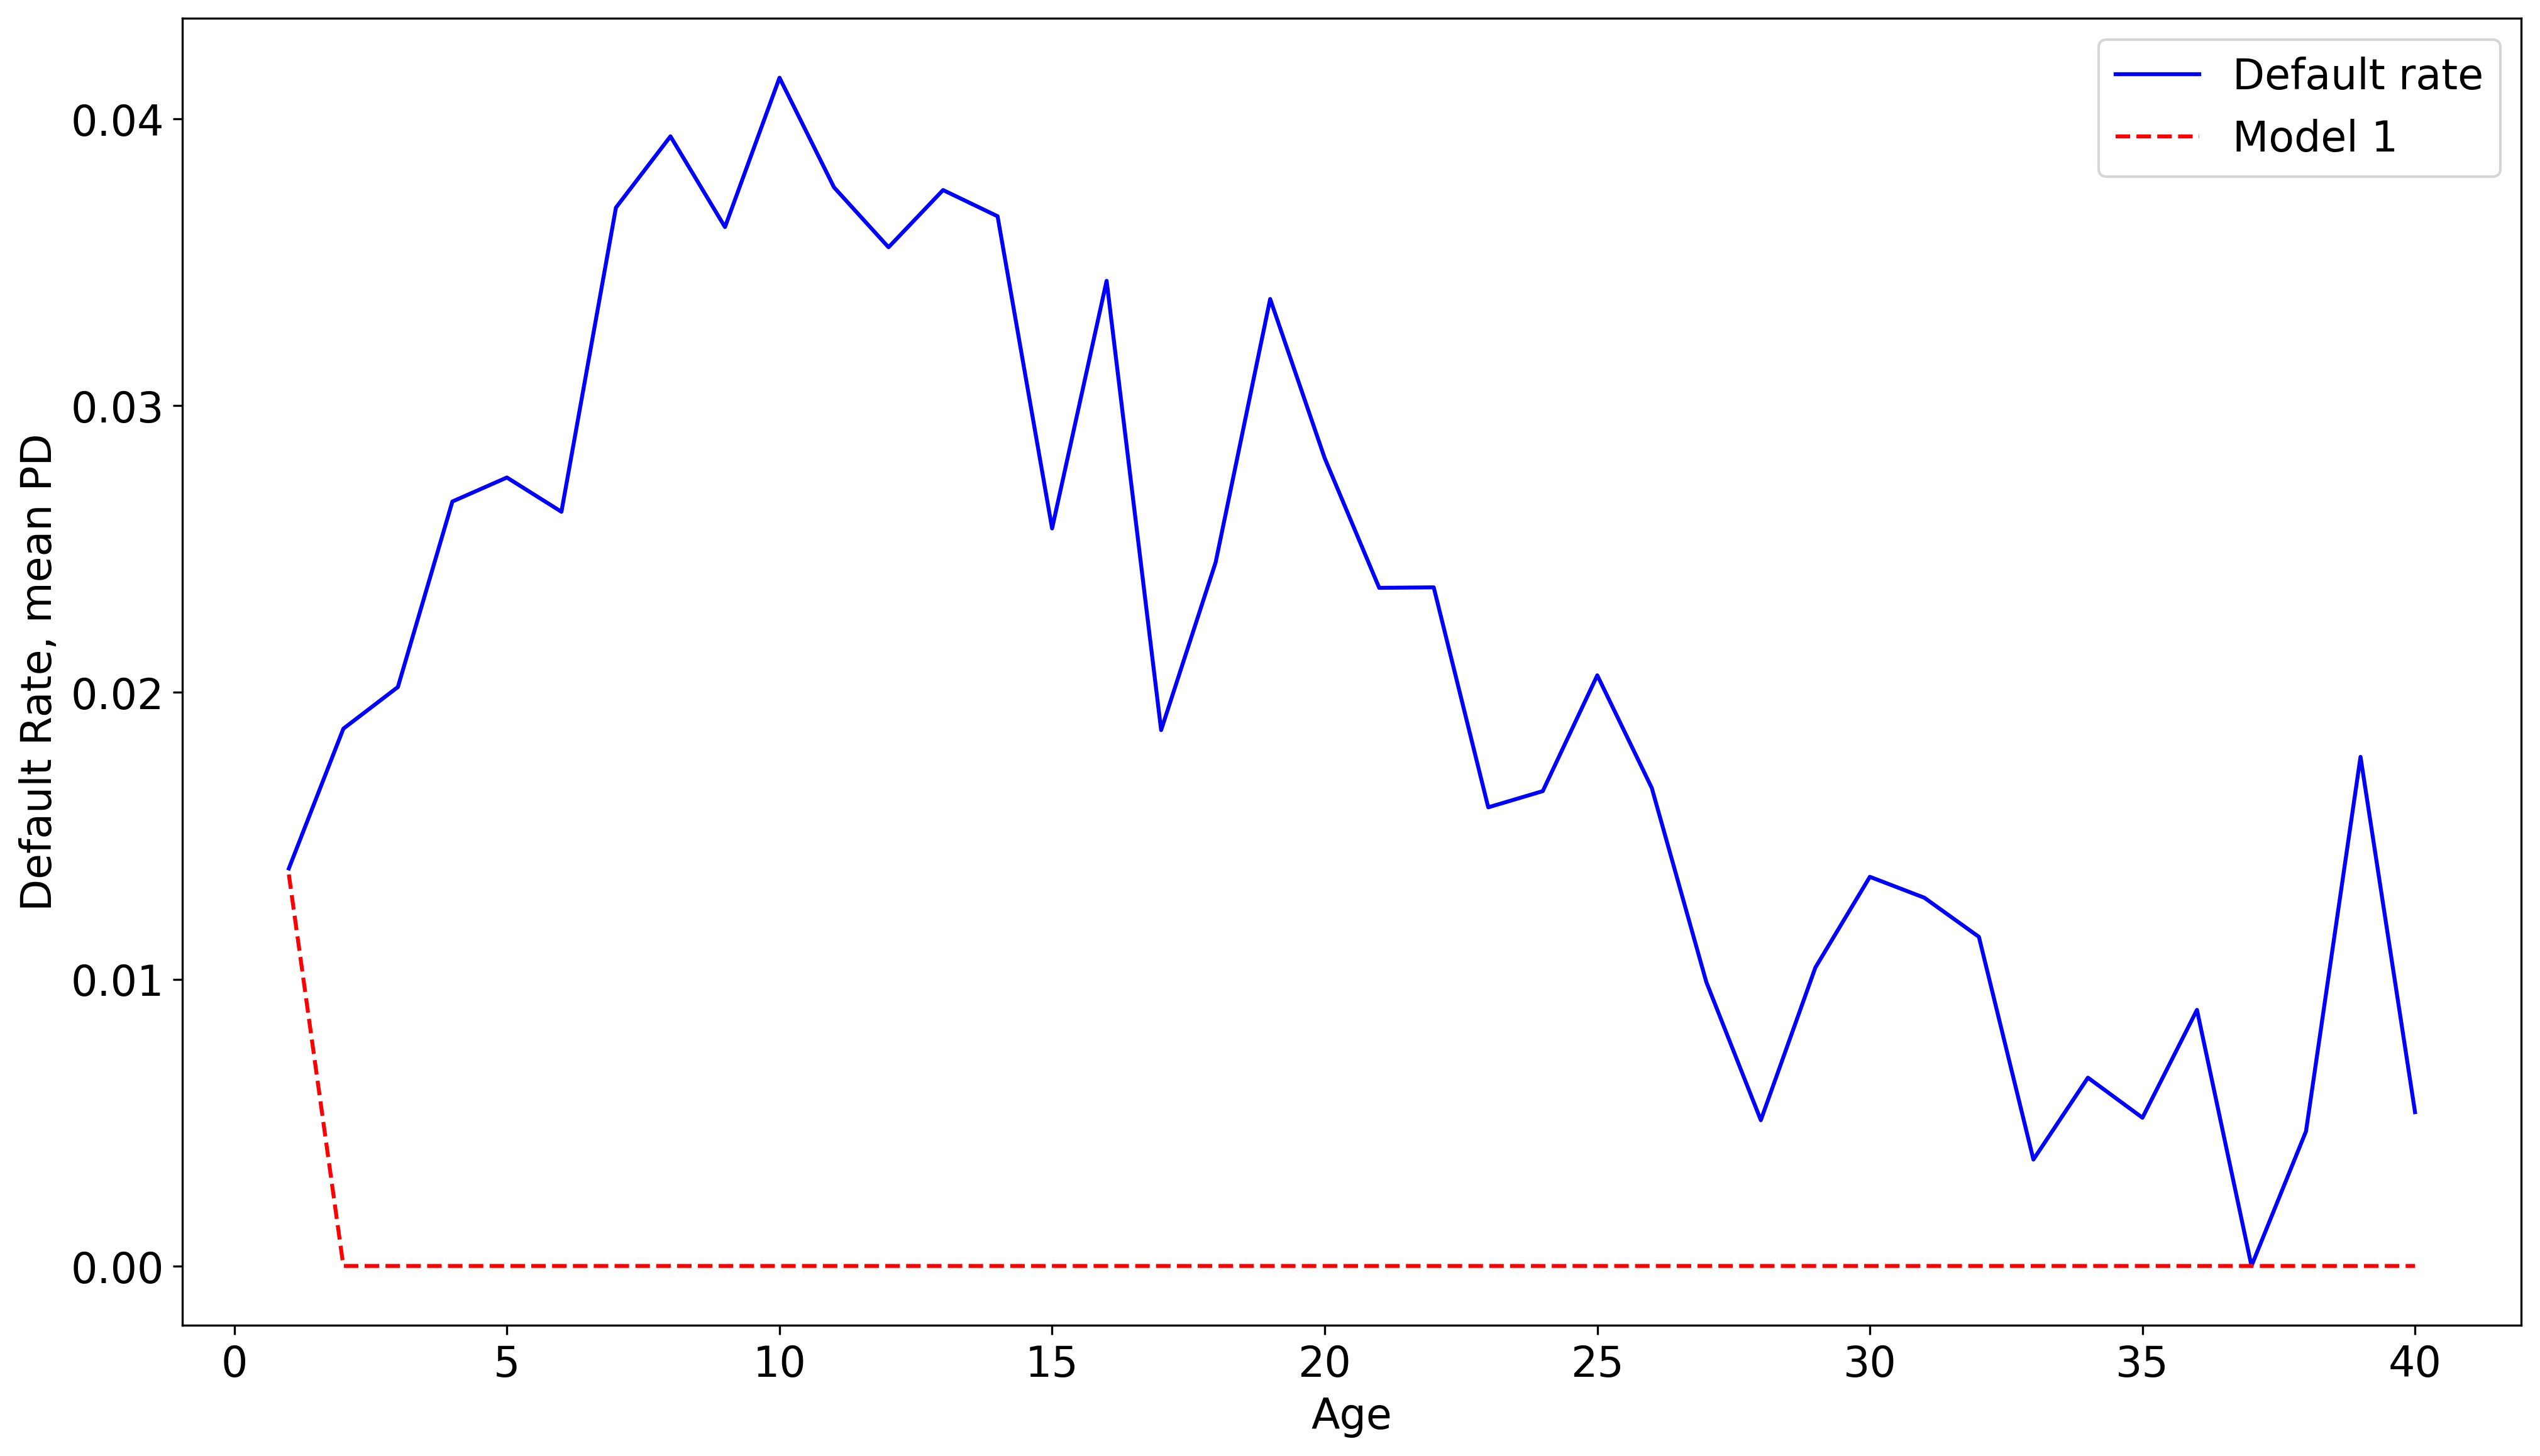

In [53]:
data3_mean_age = data3.groupby('age')[['default_time', 'PD_time']].mean().reset_index().reset_index(drop=False)
data3_mean_age

plt.plot('age', 'default_time', data=data3_mean_age, color='blue', label='Default rate')
plt.plot('age', 'PD_time', data=data3_mean_age, color='red', label='Model 1', linestyle='dashed')
plt.xlabel('Age')
plt.ylabel('Default Rate, mean PD')
plt.legend(loc='best')
plt.show()

In [54]:
model_cph2 = CoxTimeVaryingFitter()
model_cph2.fit(data[['id', 'age_1', 'FICO_orig_time', 'equity_time', 'gdp_time', 'age', 'default_time']].dropna(),
              id_col='id', event_col='default_time', start_col='age_1',
              stop_col='age', show_progress=True)

Iteration 1: norm_delta = 5.50e-01, step_size = 0.9500, log_lik = -11205.89115, newton_decrement = 2.73e+02, seconds_since_start = 0.0
Iteration 2: norm_delta = 1.47e-01, step_size = 0.9500, log_lik = -12425.80597, newton_decrement = 1.42e+03, seconds_since_start = 0.0
Iteration 3: norm_delta = 7.09e-02, step_size = 0.9500, log_lik = -11061.48167, newton_decrement = 5.05e+01, seconds_since_start = 0.1
Iteration 4: norm_delta = 3.06e-02, step_size = 1.0000, log_lik = -11002.25929, newton_decrement = 1.11e+01, seconds_since_start = 0.1
Iteration 5: norm_delta = 1.38e-02, step_size = 1.0000, log_lik = -10989.18949, newton_decrement = 1.26e+00, seconds_since_start = 0.1
Iteration 6: norm_delta = 2.27e-03, step_size = 1.0000, log_lik = -10987.82626, newton_decrement = 2.60e-02, seconds_since_start = 0.1
Iteration 7: norm_delta = 5.25e-05, step_size = 1.0000, log_lik = -10987.79991, newton_decrement = 1.32e-05, seconds_since_start = 0.1
Iteration 8: norm_delta = 2.71e-08, step_size = 1.0000,

<lifelines.CoxTimeVaryingFitter: fitted with 59001 periods, 4788 subjects, 1468 events>